# RSS Change for a Given Gamma

Examines how the RSS of packets changes while the angle the transmitter faces when it transmits those packets remains constant.

For the `Range Trials/` experiments, the tag didn't move at all, meaning there should be very little change.

In [28]:
from BleFinley import *
from ble_logs import BleLogStatic

tx_a = Transmitter('a', -1.448596, 53.368606, 131.0 + 1.5)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0 + 1.5)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0 + 1.5)
tx_e = Transmitter('e', -1.449990, 53.369204, 118.0 + 1.5)

In [29]:
from matplotlib import pyplot as plt

def rss_diff_at_gamma(ble_log :BleLog, gamma :float, packet_gap = 1) -> list[int]:
    rss_at_gamma = ble_log.all_rss_at_gamma(gamma)
    rss_differences = []

    for x in range(len(rss_at_gamma) - packet_gap):
        rss_differences.append(rss_at_gamma[x] - rss_at_gamma[x + packet_gap])

    return rss_differences

## Examine Range Trial 7

Look at the difference in RSS just for gamma = 0, and then look at a combined histogram of all angles from 0-360 degrees.

BleLog | tx: c, no.packets: 1533, time: 86.140s


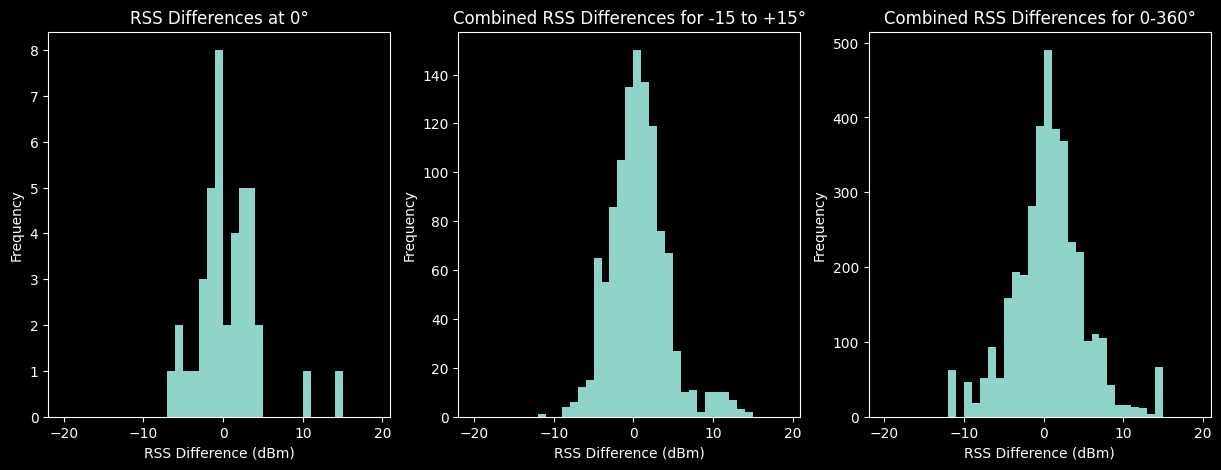

In [42]:
import numpy as np

range_7_log = BleLog("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/7.log", tx_c, None)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.title("RSS Differences at 0°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.hist(rss_diff_at_gamma(range_7_log, 0), bins=np.arange(-20, 20))

plt.subplot(1, 3, 2)
diffs = []

for degree in range(-15, 15):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title(f"Combined RSS Differences for -15 to +15°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")

plt.subplot(1, 3, 3)
diffs = []

for degree in range(0, 359):
    diffs.extend(rss_diff_at_gamma(range_7_log, degree))

plt.hist(diffs, bins=np.arange(-20, 20))
plt.title("Combined RSS Differences for 0-360°")
plt.ylabel("Frequency")
plt.xlabel("RSS Difference (dBm)")
plt.show()

## Examine All Range Trials Together

For all the range trials in `/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/`, examine the difference in RSS between two packets (sequential or with a large gap between them) for a given gamma. Collate this information into blocks of 30 degrees and then combine the data for all angles. The values of gamma for each packet are normalised so 0 degrees is pointing directly at the bee tag.

In [32]:
# parse all range trials into a dictionary
range_logs :dict[str, BleLog] = {}
range_trial_folder = "/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/Range Trials/"

range_logs["1.log"] = BleLogStatic(range_trial_folder + "1.log", tx_c, -1.449861, 53.368415, 128.1)
range_logs["2.log"] = BleLogStatic(range_trial_folder + "2.log", tx_c, -1.449851, 53.368798, 124.3)
range_logs["3.log"] = BleLogStatic(range_trial_folder + "3.log", tx_c, -1.449712, 53.369261, 111.0)
range_logs["4.log"] = BleLogStatic(range_trial_folder + "4.log", tx_c, -1.449732, 53.369659, 123.5)
range_logs["5.log"] = BleLogStatic(range_trial_folder + "5.log", tx_c, -1.449705, 53.369932, 112.0)
range_logs["6.log"] = BleLogStatic(range_trial_folder + "6.log", tx_c, -1.449617, 53.370239, 111.2)
range_logs["7.log"] = BleLogStatic(range_trial_folder + "7.log", tx_c, -1.449647, 53.370649, 106.6)
range_logs["8.log"] = BleLogStatic(range_trial_folder + "8.log", tx_c, -1.449575, 53.371191, 104.9)
range_logs["9.log"] = BleLogStatic(range_trial_folder + "9.log", tx_c, -1.449595, 53.371545, 107.7)

BleLog | tx: c, no.packets: 8314, time: 86.369s
BleLogStatic | angle offset: -74.055
BleLog | tx: c, no.packets: 3108, time: 75.356s
BleLogStatic | angle offset: -23.199
BleLog | tx: c, no.packets: 3208, time: 89.925s
BleLogStatic | angle offset: -16.699
BleLog | tx: c, no.packets: 6502, time: 87.054s
BleLogStatic | angle offset: -10.929
BleLog | tx: c, no.packets: 1518, time: 91.795s
BleLogStatic | angle offset: -9.728
BleLog | tx: c, no.packets: 93, time: 71.421s
BleLogStatic | angle offset: -9.507
BleLog | tx: c, no.packets: 1533, time: 86.140s
BleLogStatic | angle offset: -7.374
BleLog | tx: c, no.packets: 1536, time: 96.692s
BleLogStatic | angle offset: -6.699
BleLog | tx: c, no.packets: 2864, time: 73.173s
BleLogStatic | angle offset: -5.807


In [33]:
from IPython.display import display, Markdown
from scipy.stats import norm

def range_trial_rss_diffs_in_blocks(range_trials, packet_gap = 1, log = False):
    for start_angle in range (-15, 360 - 15, 30):
        display(Markdown(f"#### {start_angle} to {(start_angle + 30) % 360} Degrees"))
        plt.figure(figsize=(27, 5))
        graph_num = 1
        combined_diffs = []

        for name, ble_log in range_trials.items():
            diffs = []

            for angle in range(start_angle, start_angle + 29):
                diffs.extend(rss_diff_at_gamma(ble_log, angle, packet_gap))

            combined_diffs.extend(diffs)

            plt.subplot(1, 10, graph_num)
            plt.hist(diffs, bins=np.arange(-20, 20))
            plt.yscale("log") if log else None
            plt.title(name)
            graph_num += 1

        # draw combined graph
        plt.subplot(1, 10, graph_num)
        plt.hist(combined_diffs, bins=np.arange(-20, 20))
        plt.yscale("log") if log else None
        plt.title("Combined")
        ax = plt.gca()
        ax.set_facecolor("#5E1414")
        plt.show()

def combined_rss_at_gamma_analysis(range_dict, packet_gap):
    range_rss_diffs = []

    for range_log in range_dict.values():
        for degree in range(0, 360 - 1):
            range_rss_diffs.extend(rss_diff_at_gamma(range_log, degree, packet_gap))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
    plt.title("All Range Trial Differences for All Angles")
    plt.ylabel("Frequency")
    plt.xlabel("RSS Difference (dBm)")

    plt.subplot(1, 3, 2)
    plt.hist(range_rss_diffs, bins=np.arange(-20, 20))
    plt.yscale("log")
    plt.title("Log of Differences for All Angles")
    plt.ylabel("Log of Frequency")
    plt.xlabel("Rss Difference (dBm)")

    plt.subplot(1, 3, 3)
    plt.title("Normal PDF")
    plt.plot(np.arange(-20, 20), norm.pdf(np.arange(-20, 20), np.mean(range_rss_diffs), np.std(range_rss_diffs)))
    plt.show()

### Sequential Packet Differences

The difference is taken between the current packet and the packet at the same gamma in the next transmitter rotation (approximately 2 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

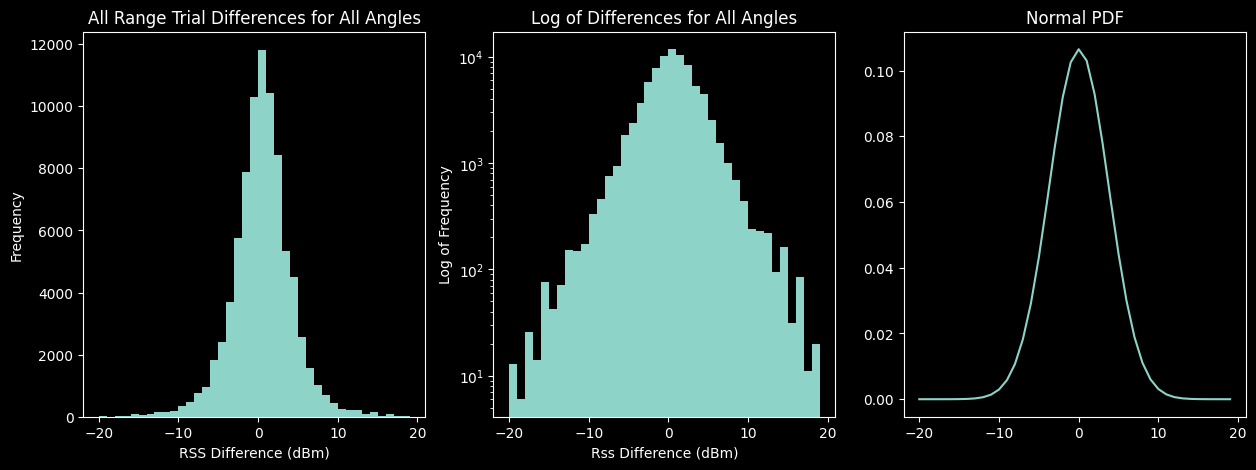

In [34]:
combined_rss_at_gamma_analysis(range_logs, 1)

#### -15 to 15 Degrees

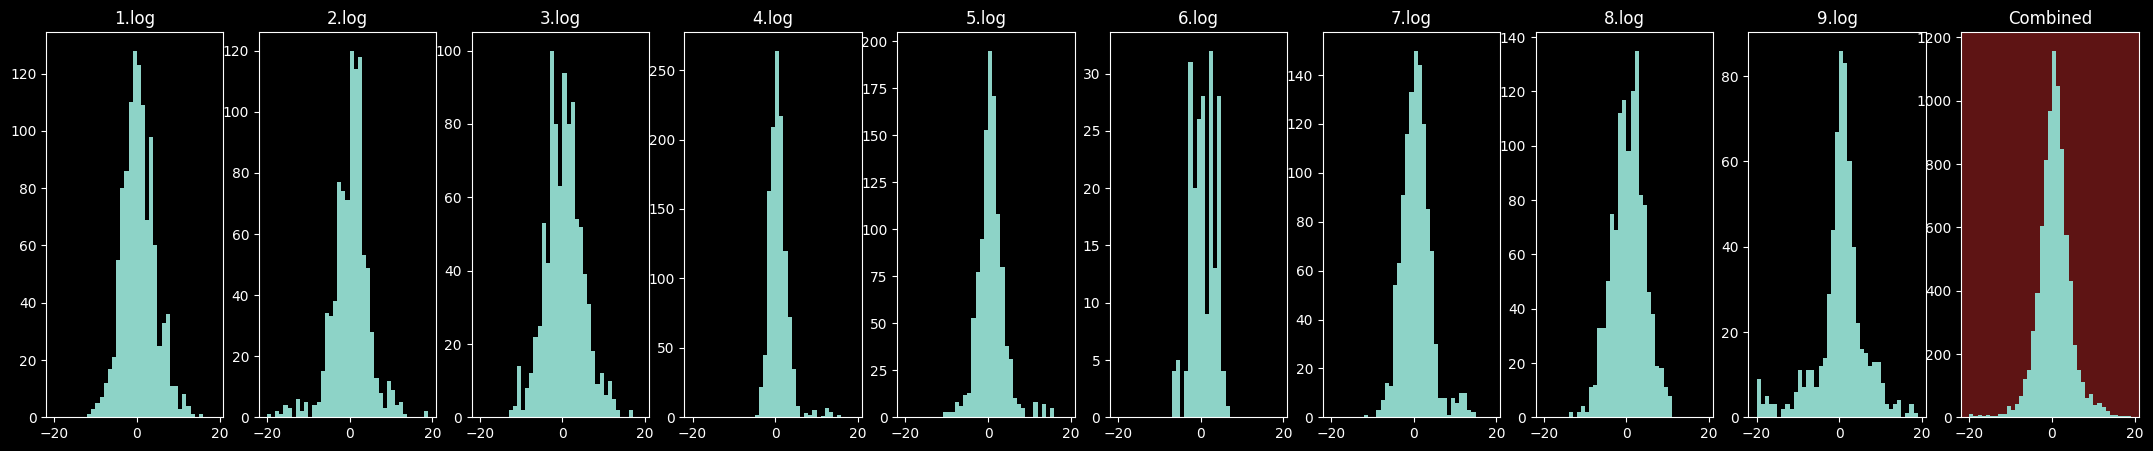

#### 15 to 45 Degrees

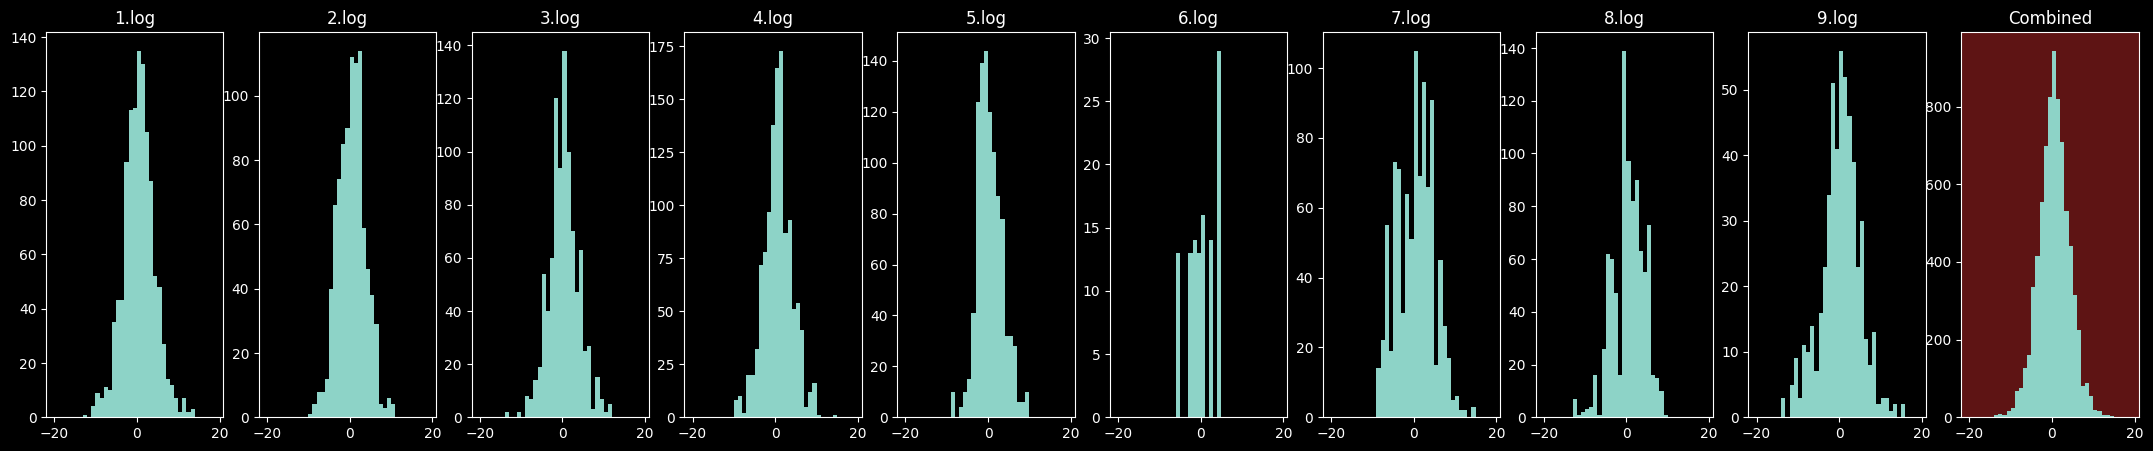

#### 45 to 75 Degrees

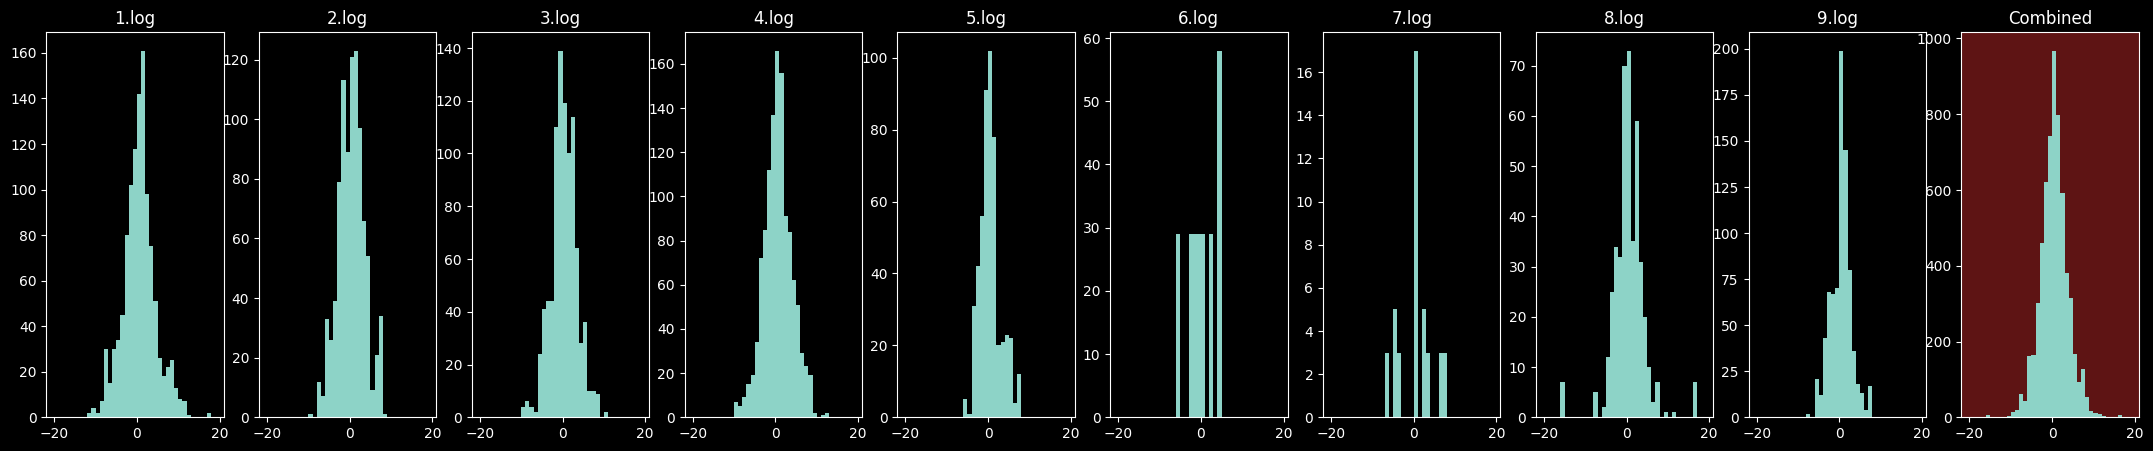

#### 75 to 105 Degrees

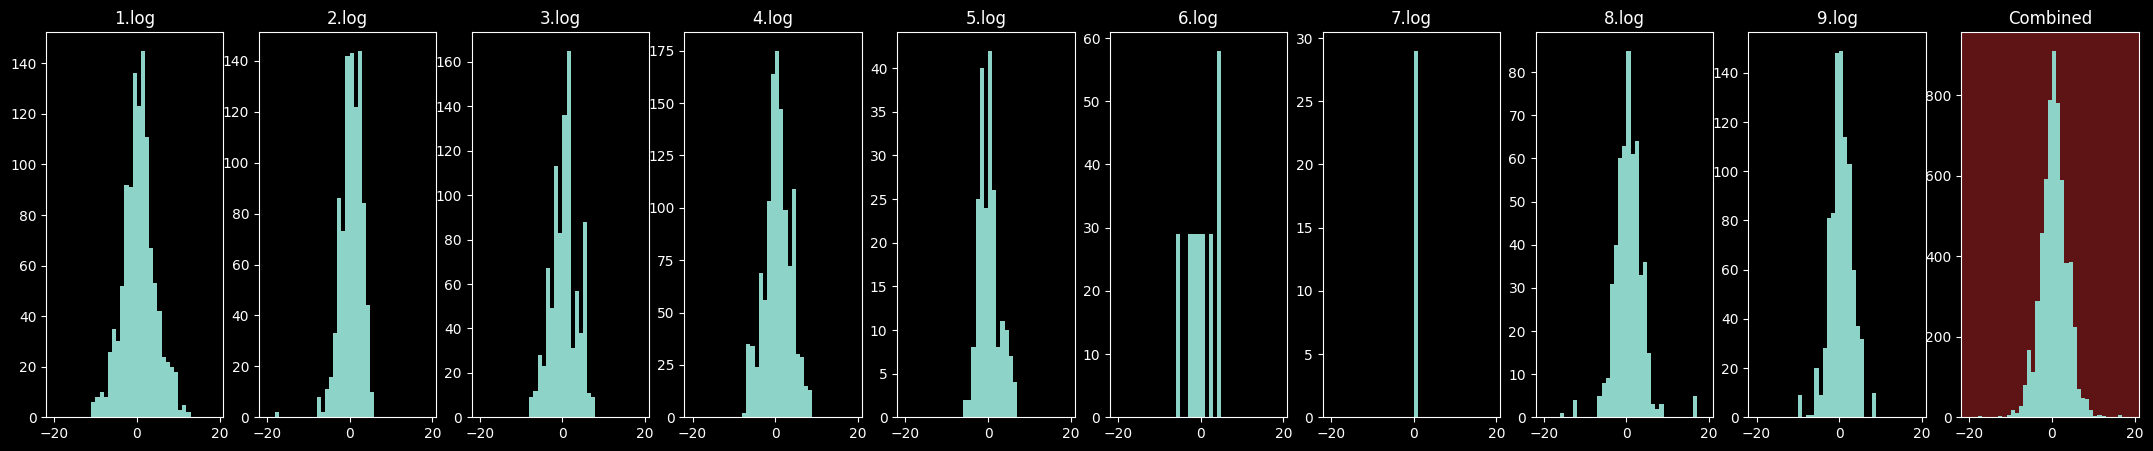

#### 105 to 135 Degrees

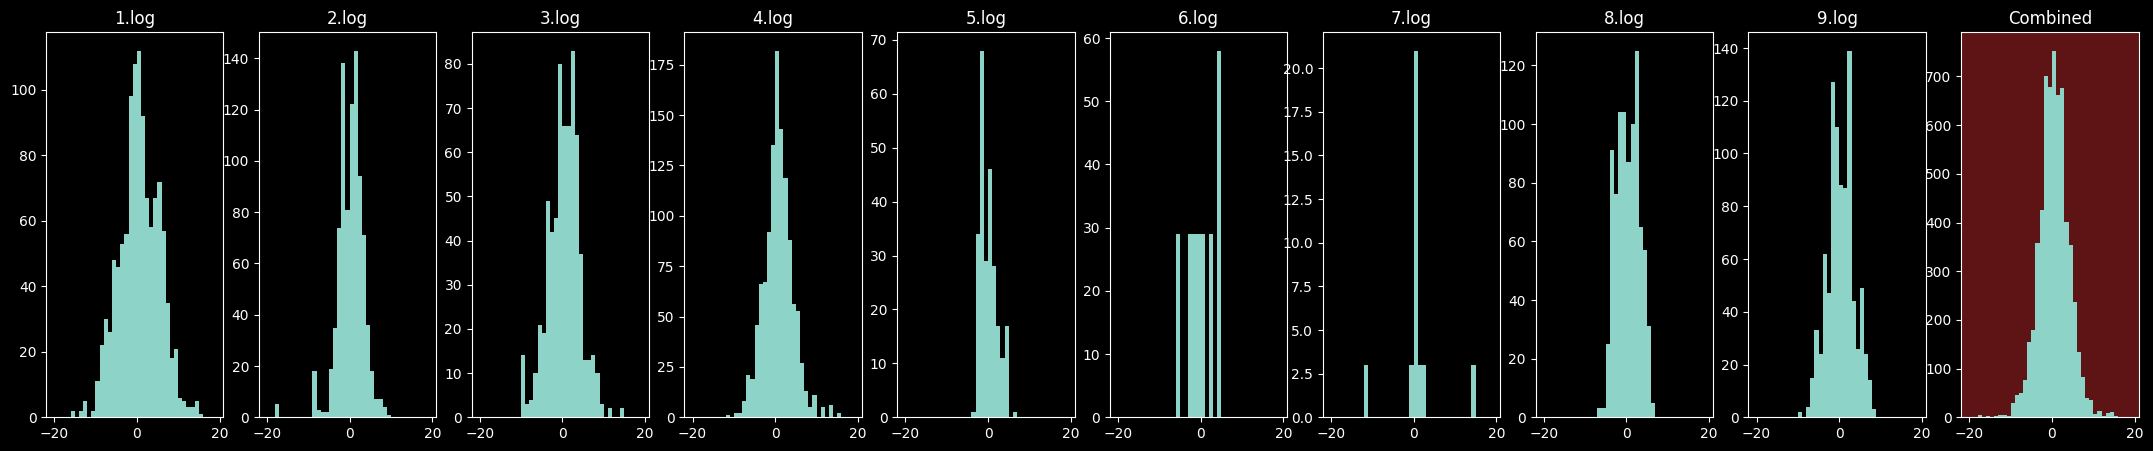

#### 135 to 165 Degrees

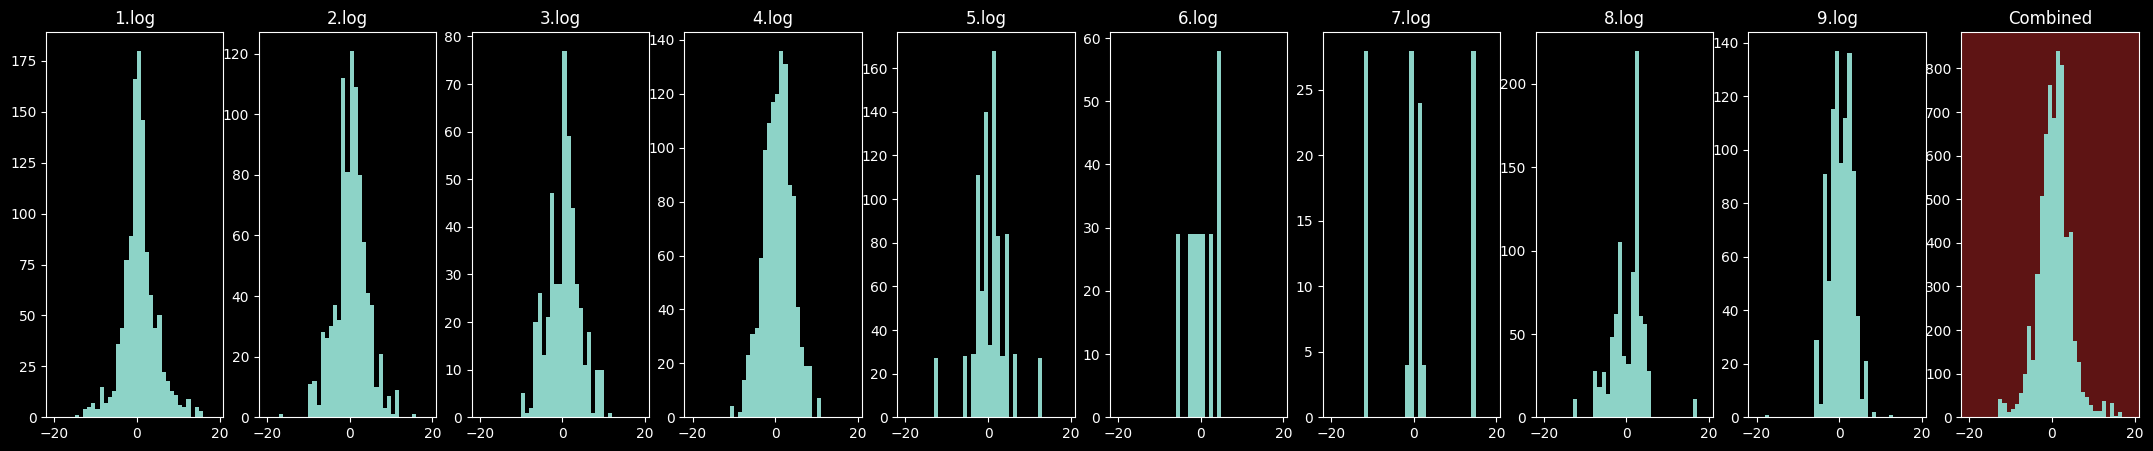

#### 165 to 195 Degrees

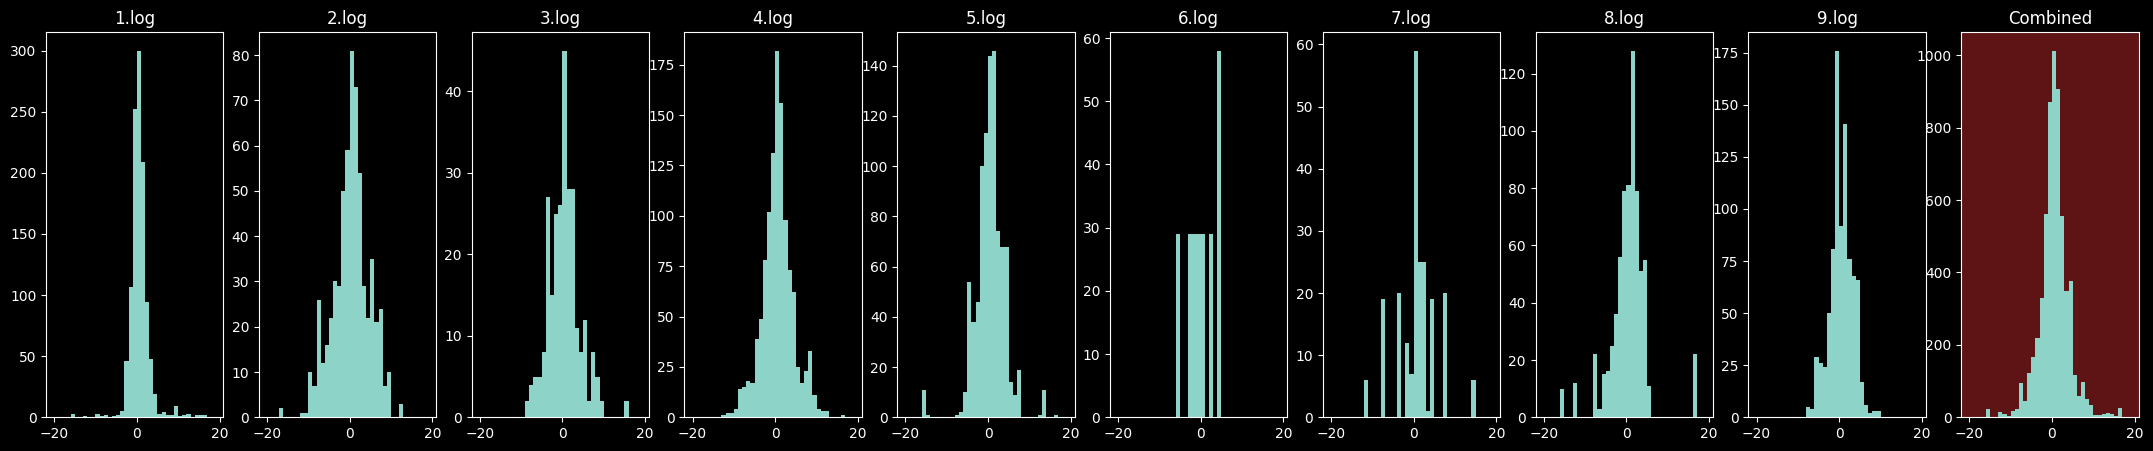

#### 195 to 225 Degrees

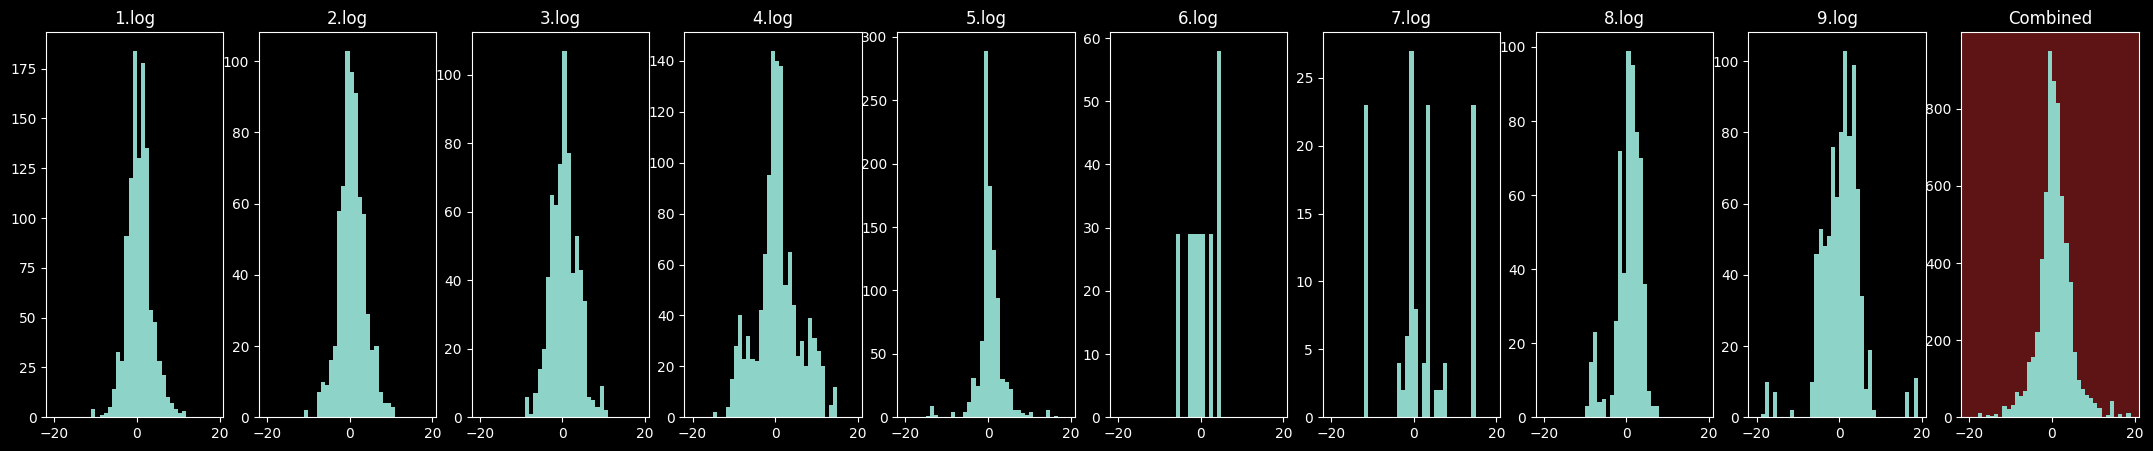

#### 225 to 255 Degrees

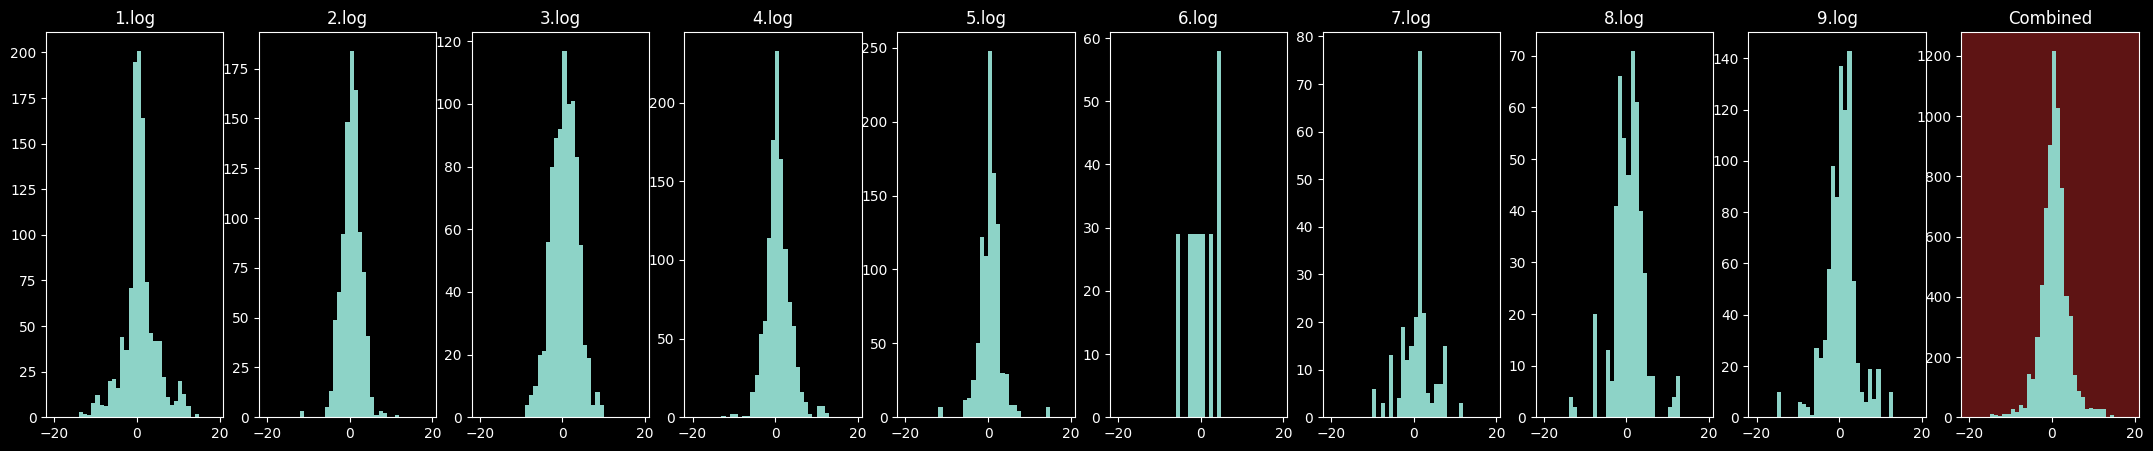

#### 255 to 285 Degrees

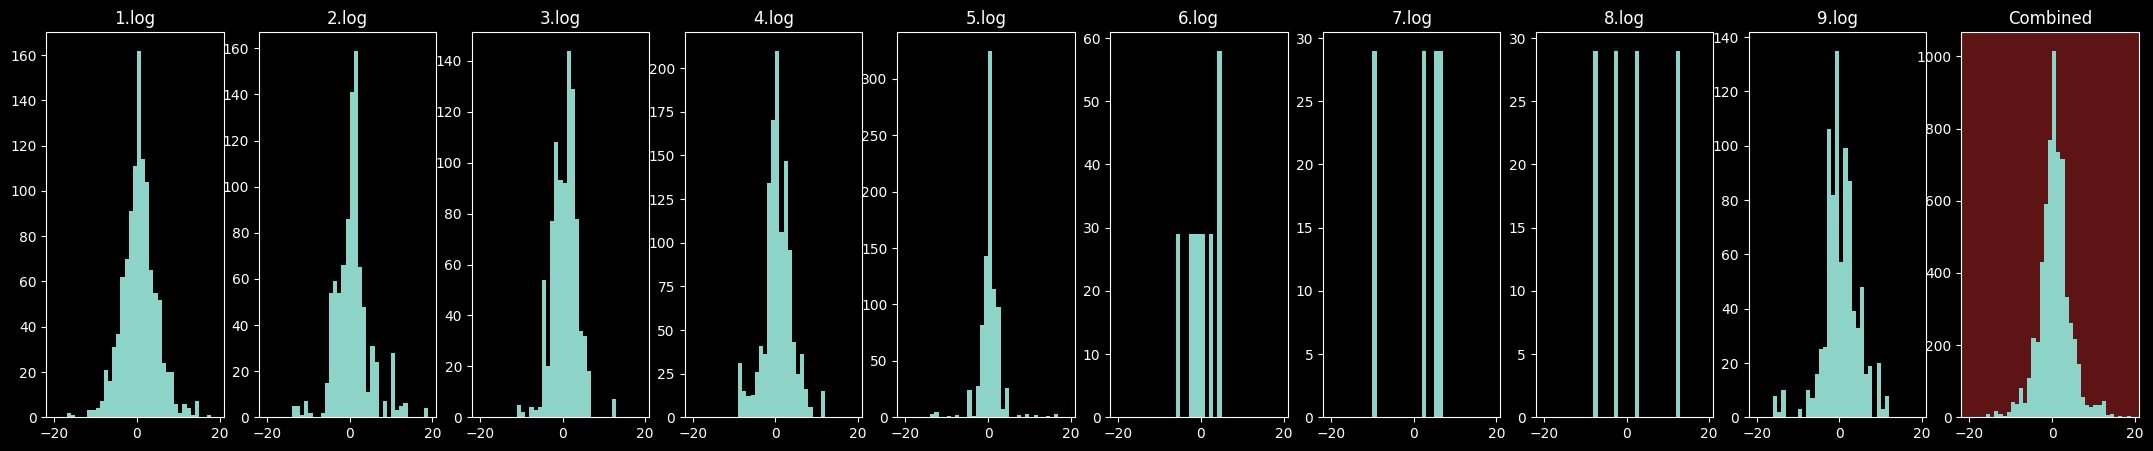

#### 285 to 315 Degrees

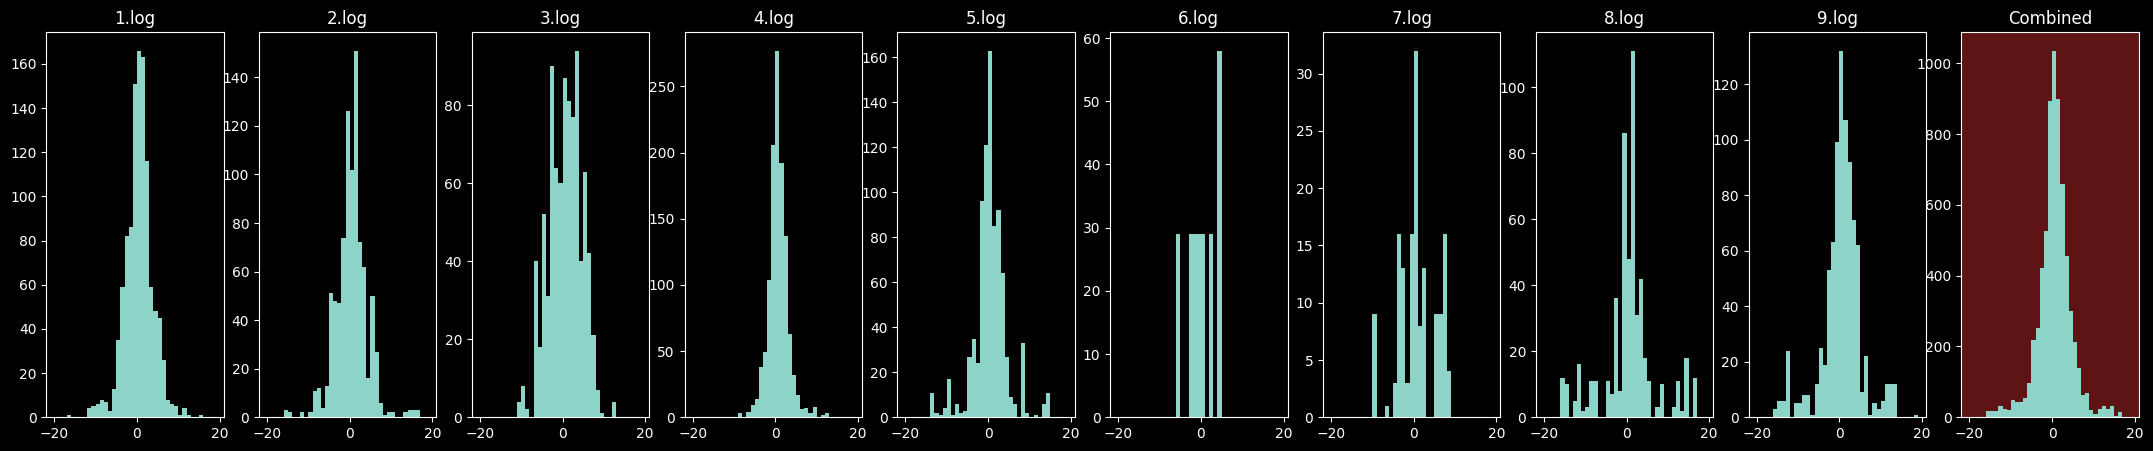

#### 315 to 345 Degrees

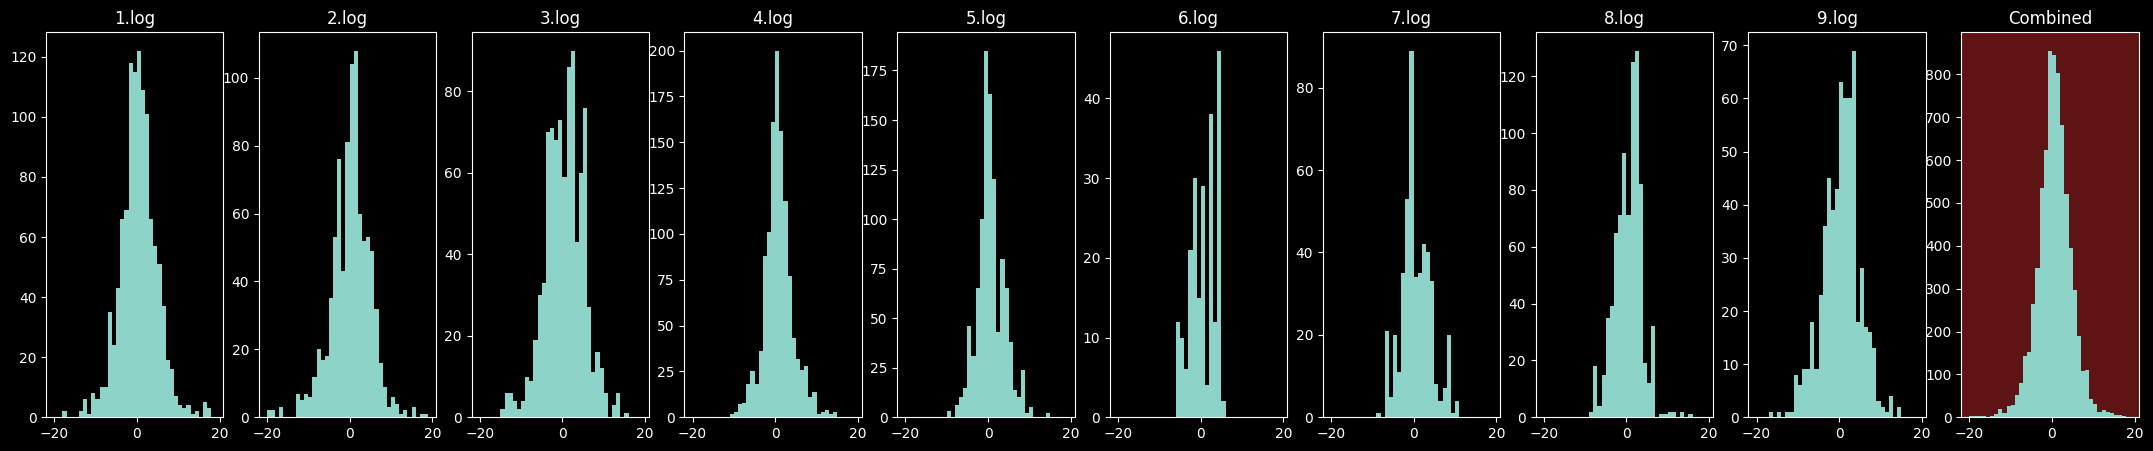

In [35]:
range_trial_rss_diffs_in_blocks(range_logs)

### Five Packet Differences

The difference is taken between the current packet and the packet at the same gamma in five transmitter-rotations' time (approximately 10 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

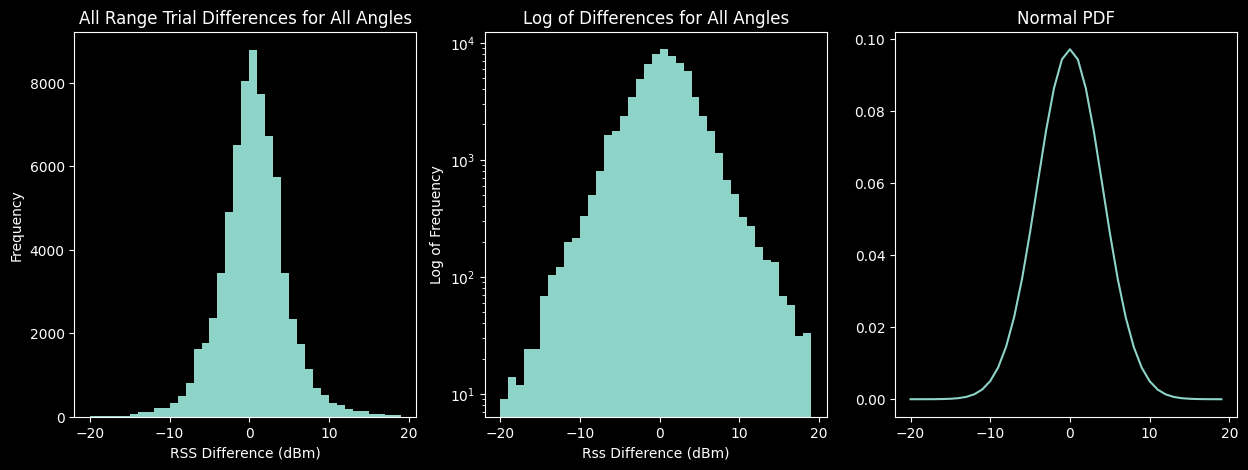

In [36]:
combined_rss_at_gamma_analysis(range_logs, 5)

#### -15 to 15 Degrees

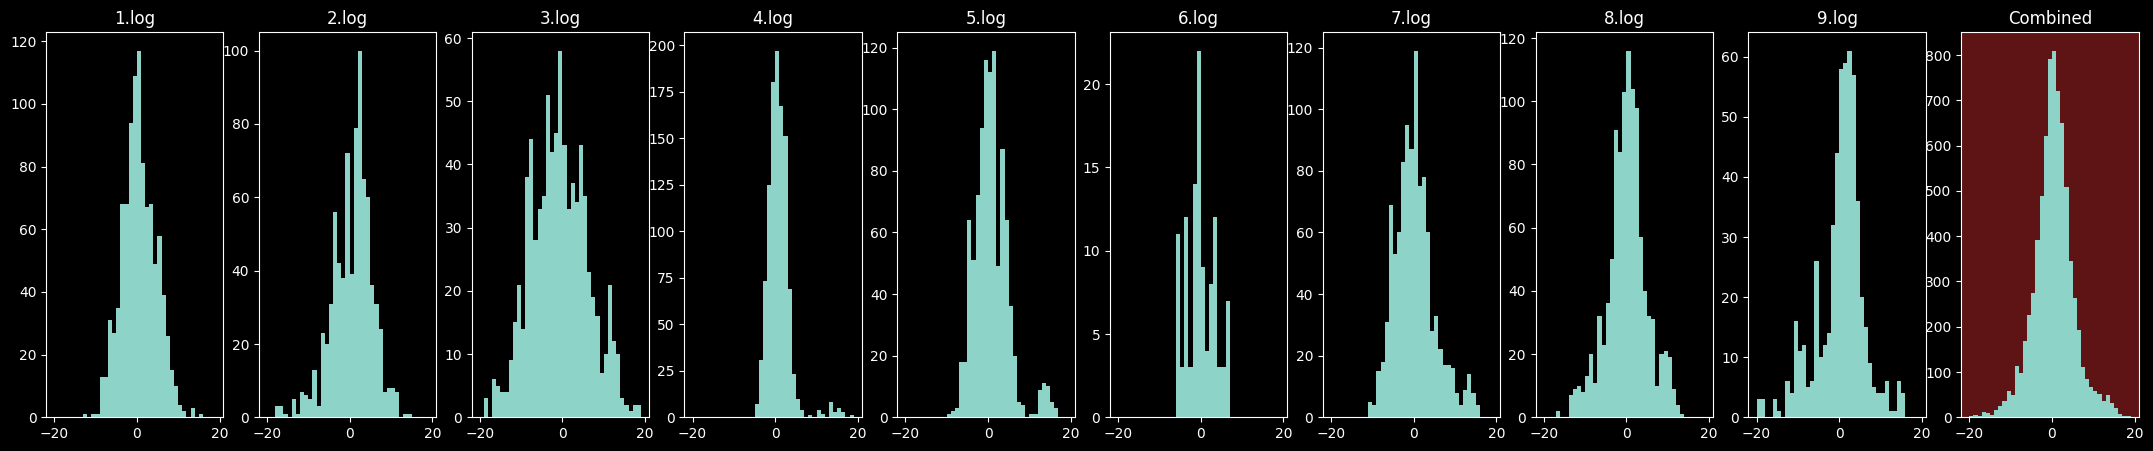

#### 15 to 45 Degrees

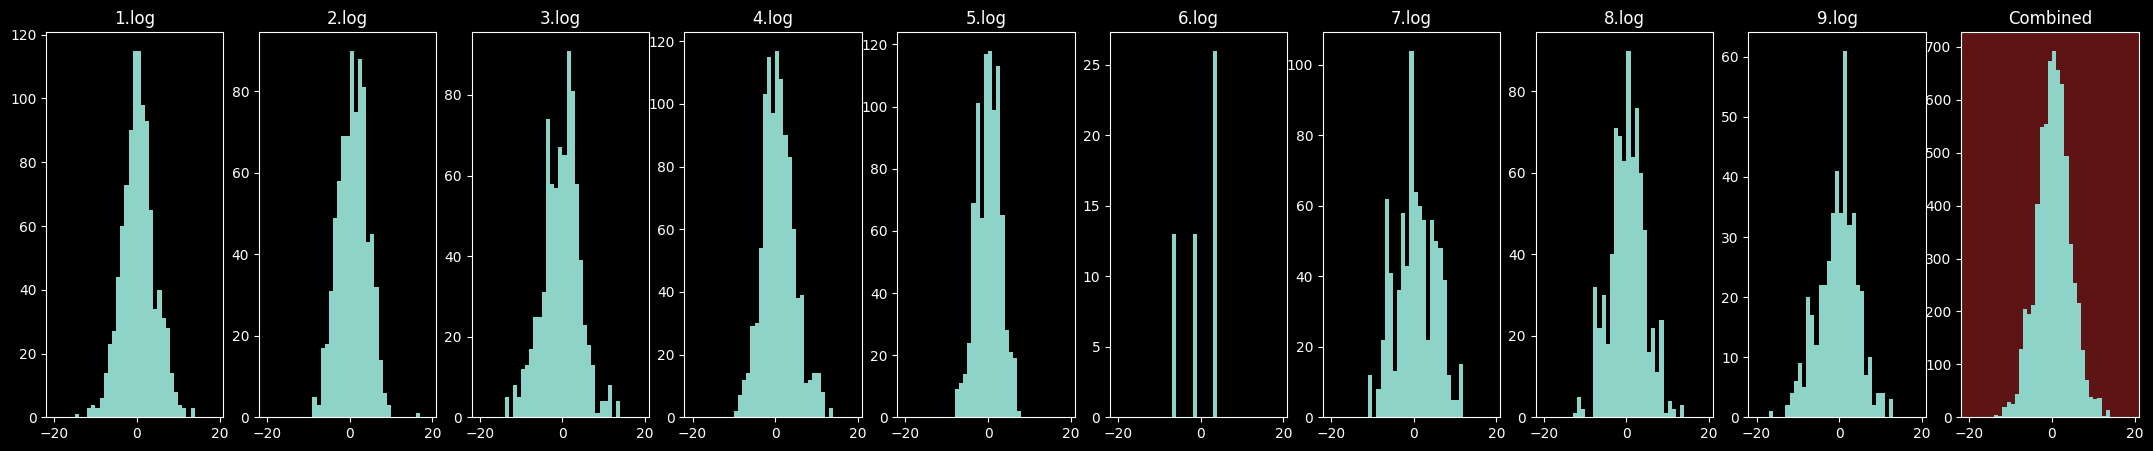

#### 45 to 75 Degrees

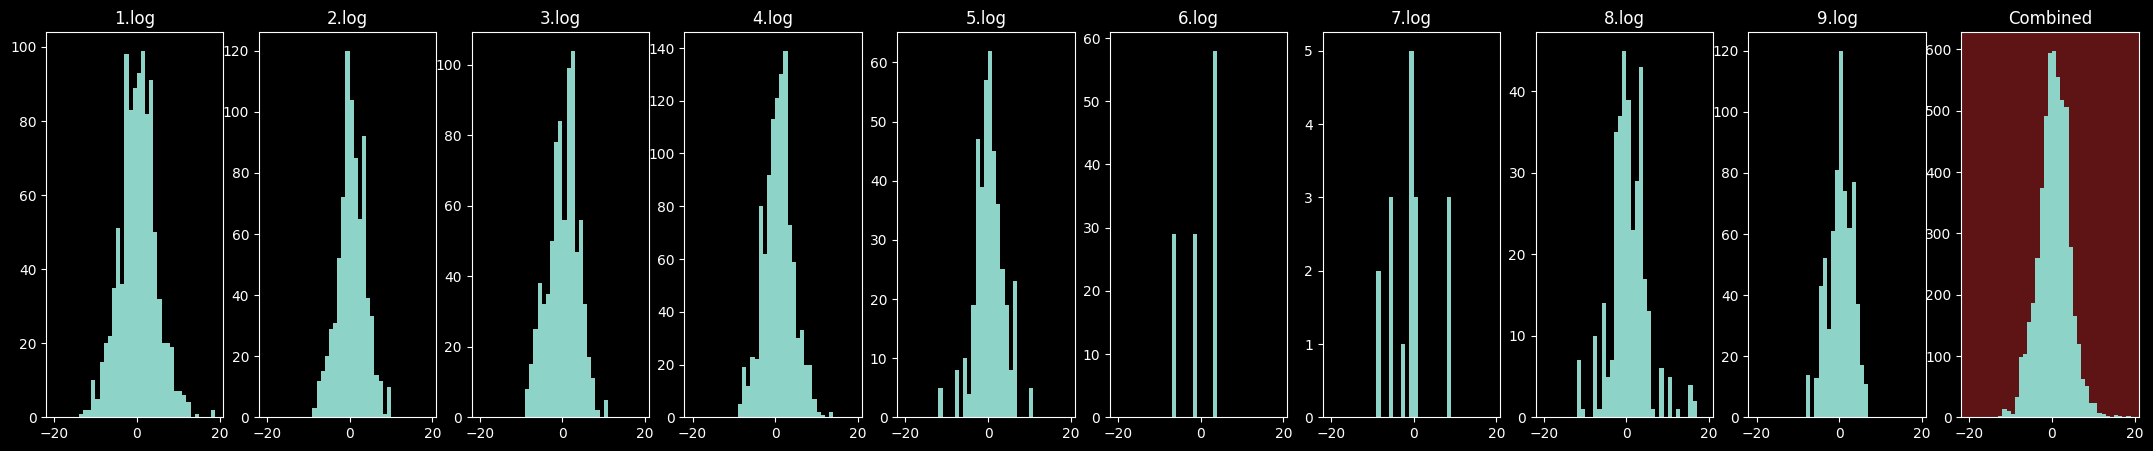

#### 75 to 105 Degrees

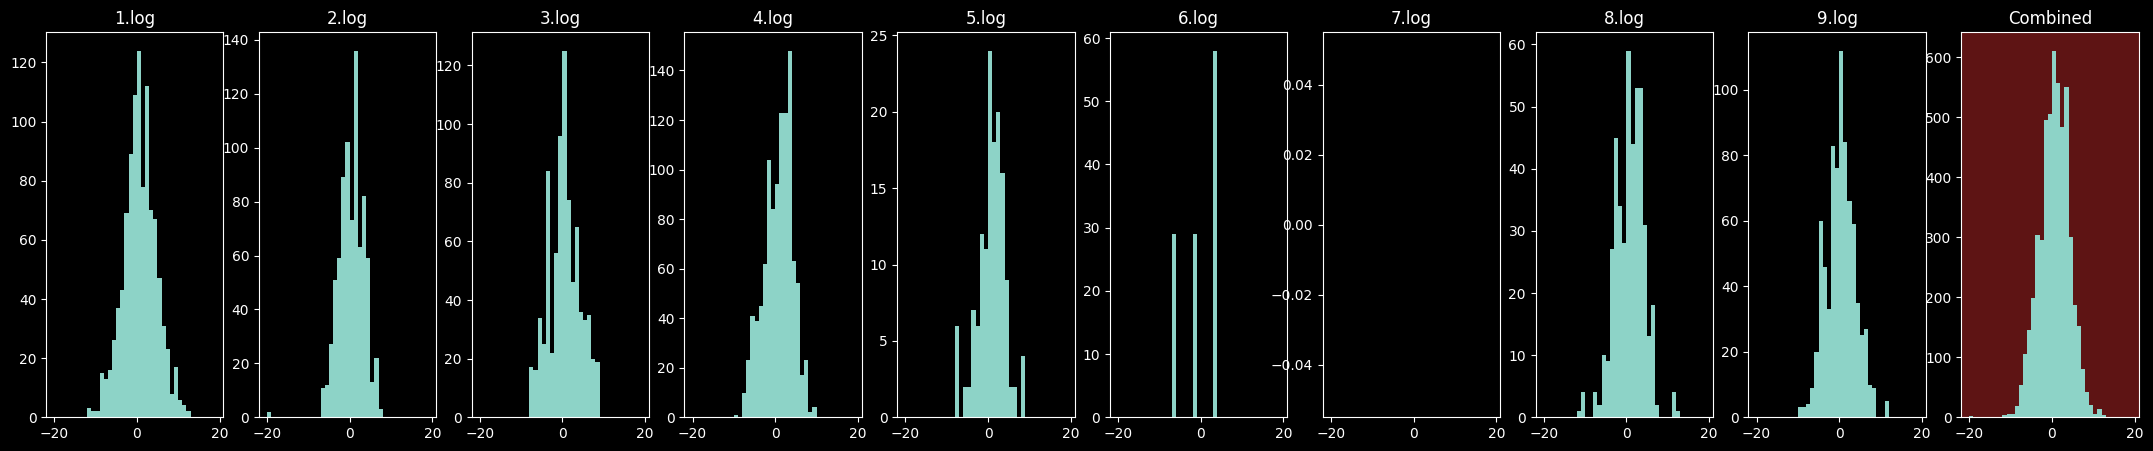

#### 105 to 135 Degrees

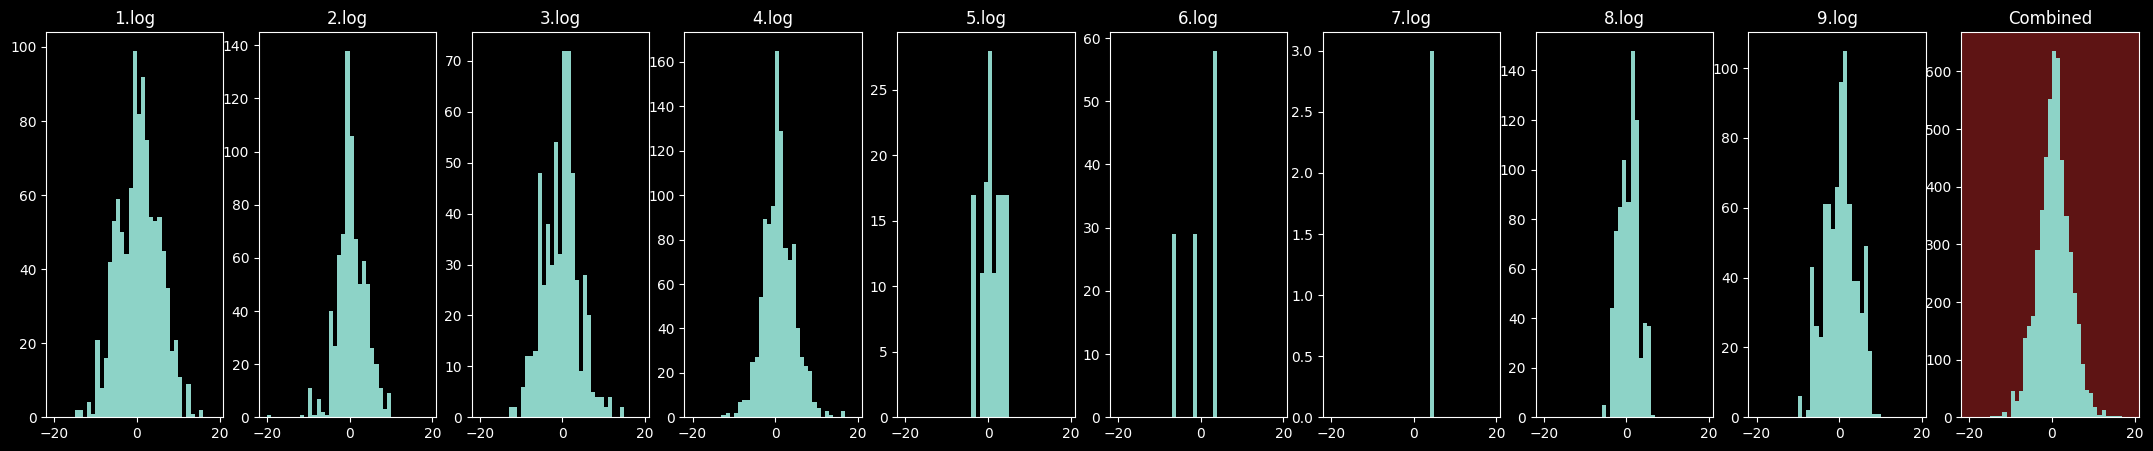

#### 135 to 165 Degrees

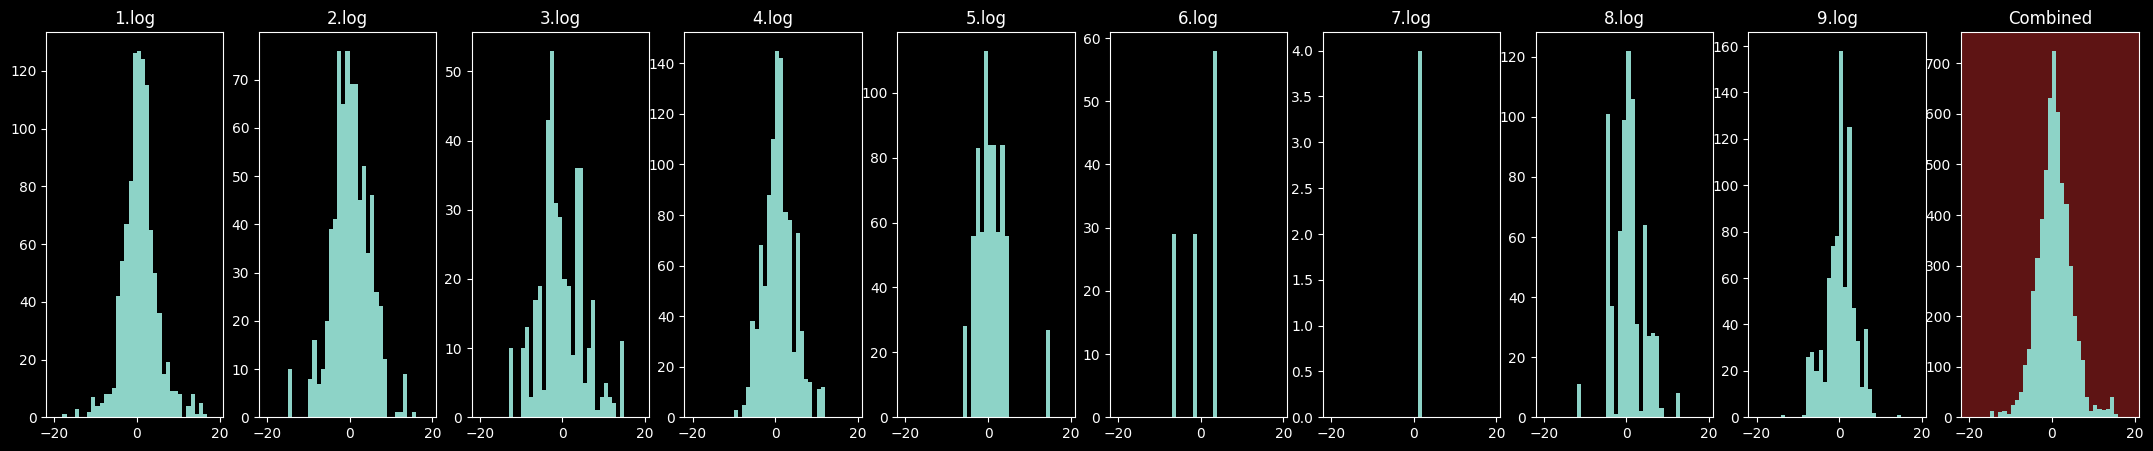

#### 165 to 195 Degrees

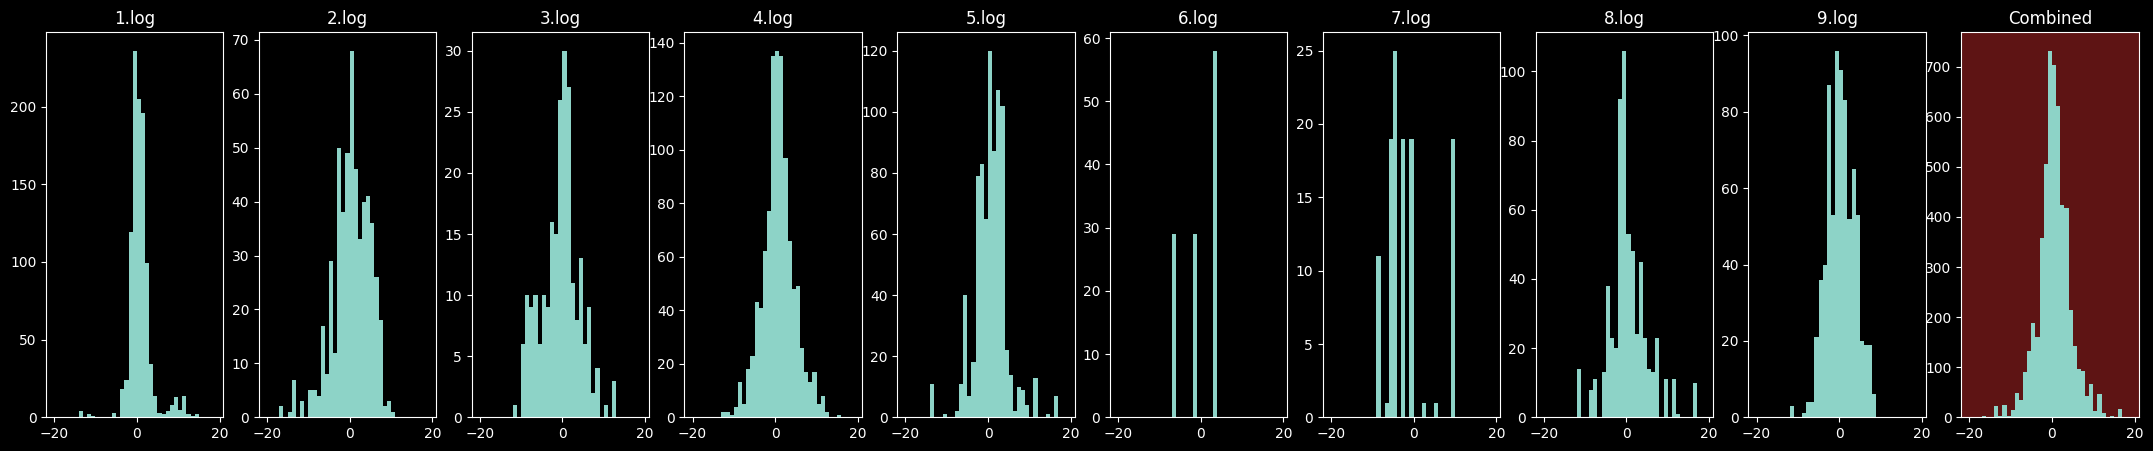

#### 195 to 225 Degrees

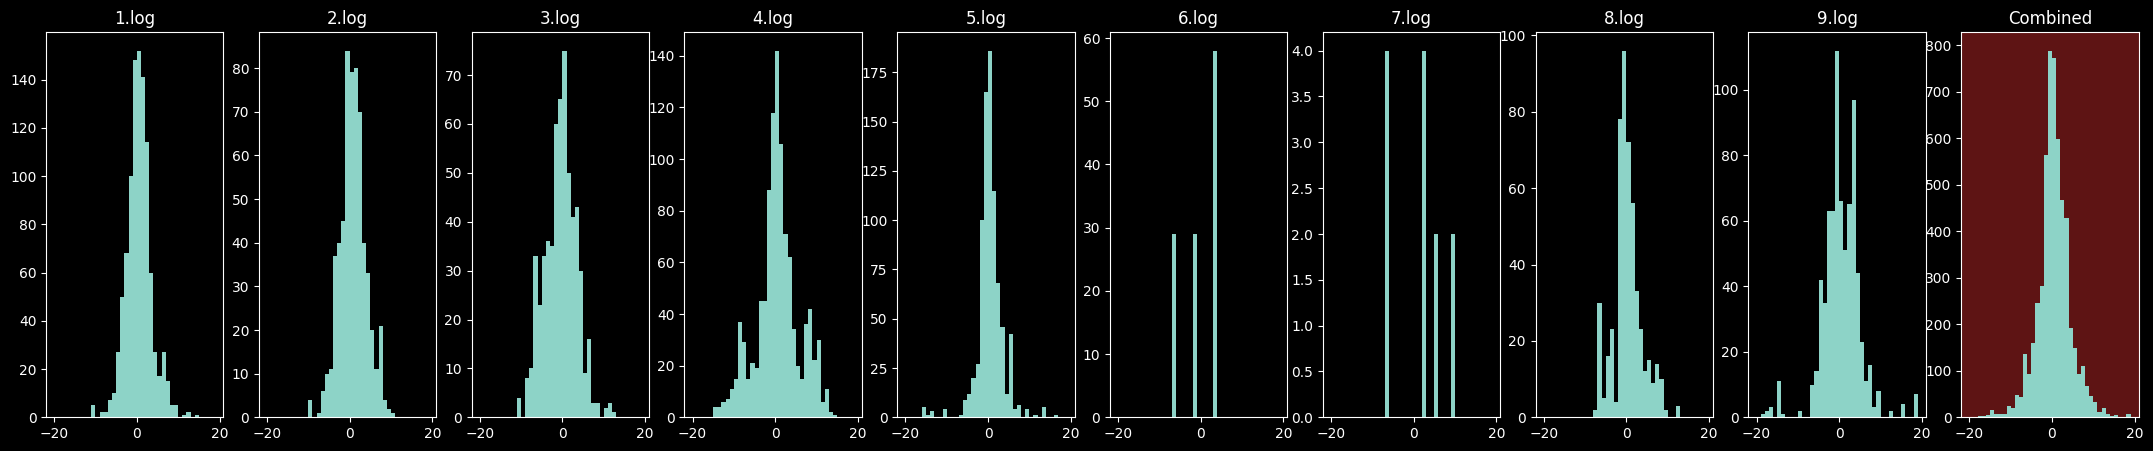

#### 225 to 255 Degrees

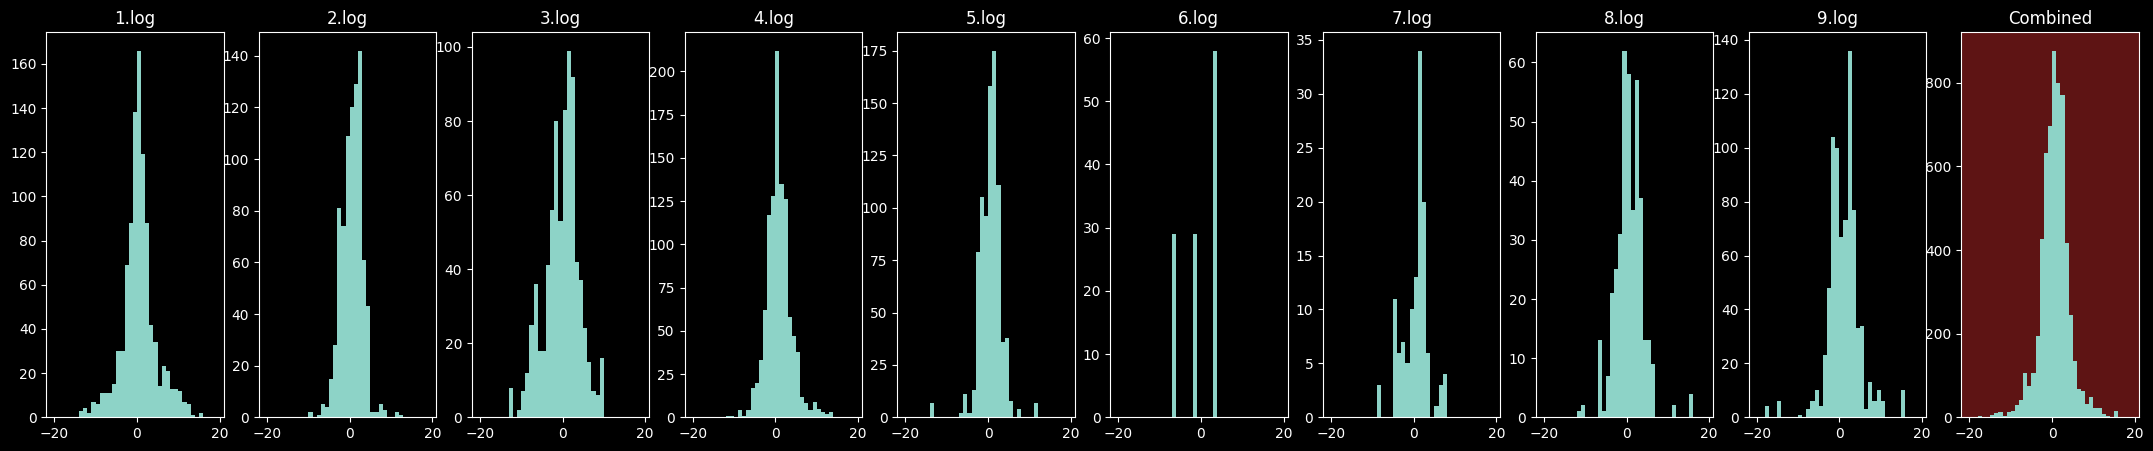

#### 255 to 285 Degrees

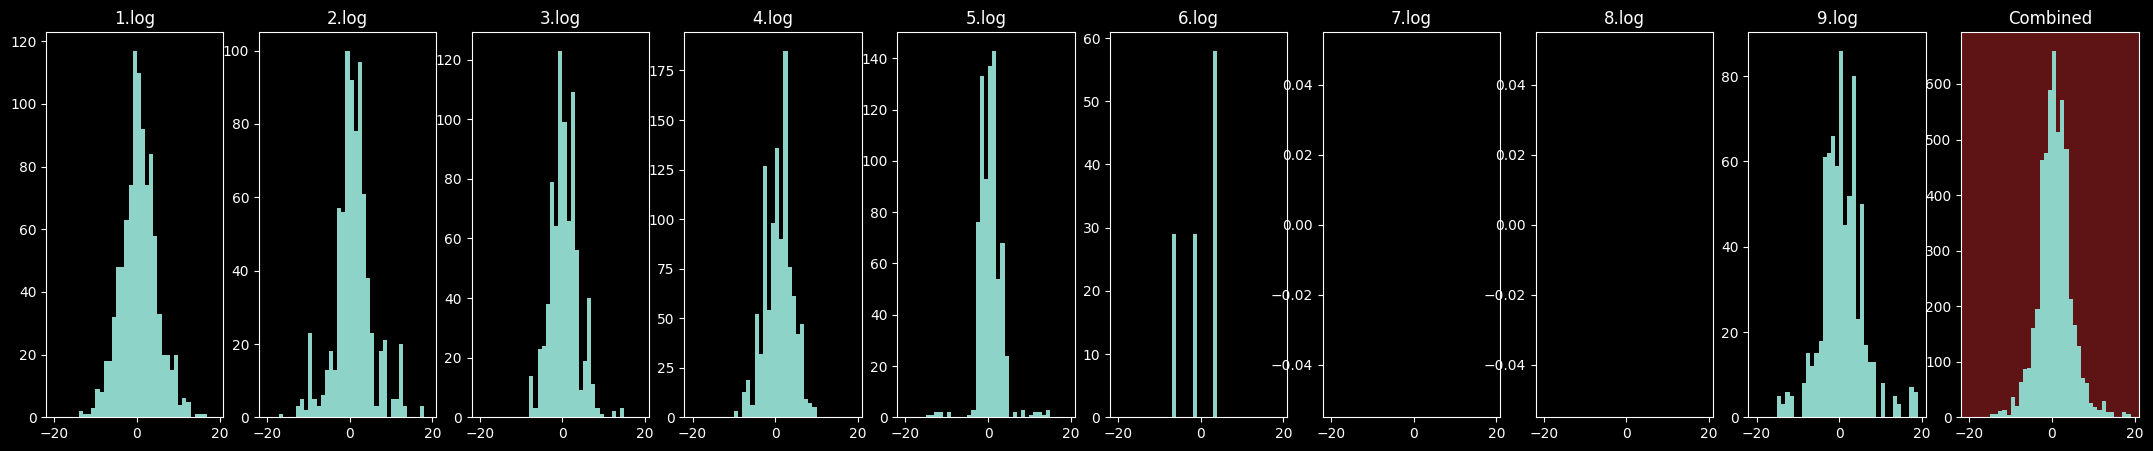

#### 285 to 315 Degrees

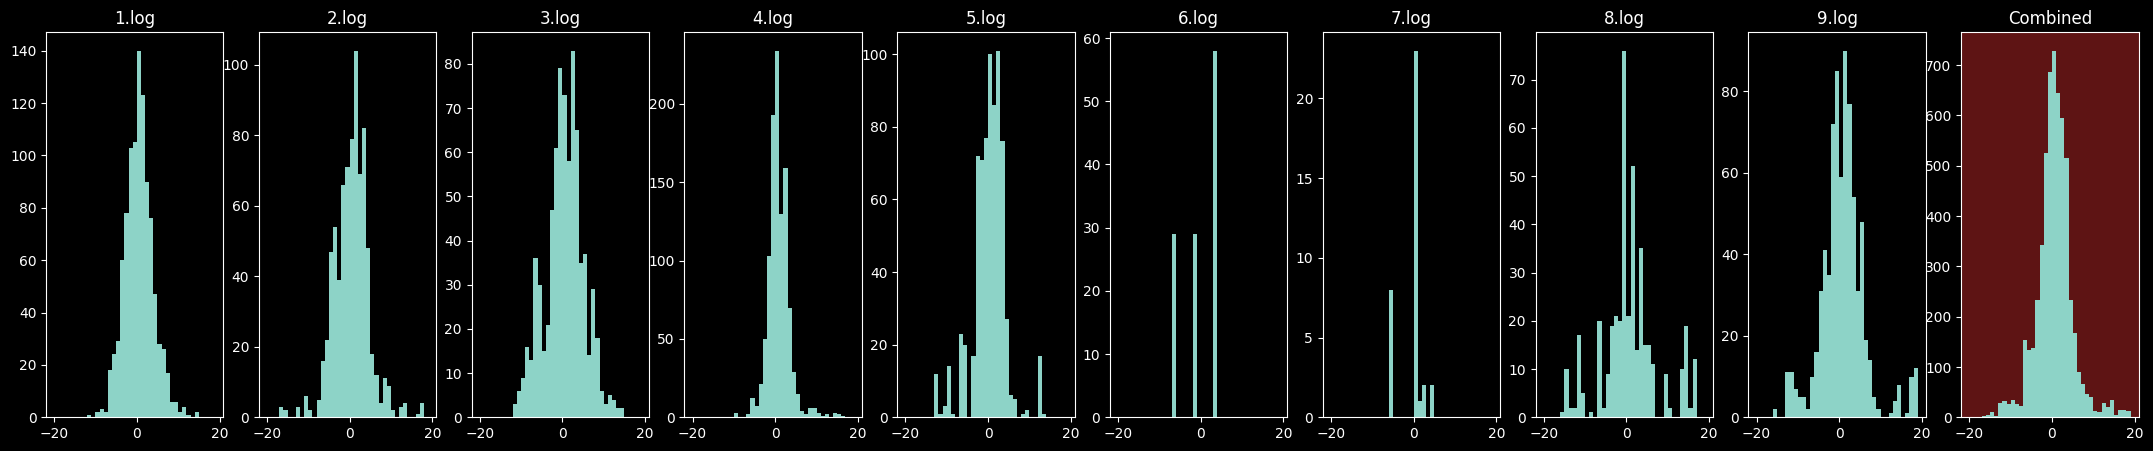

#### 315 to 345 Degrees

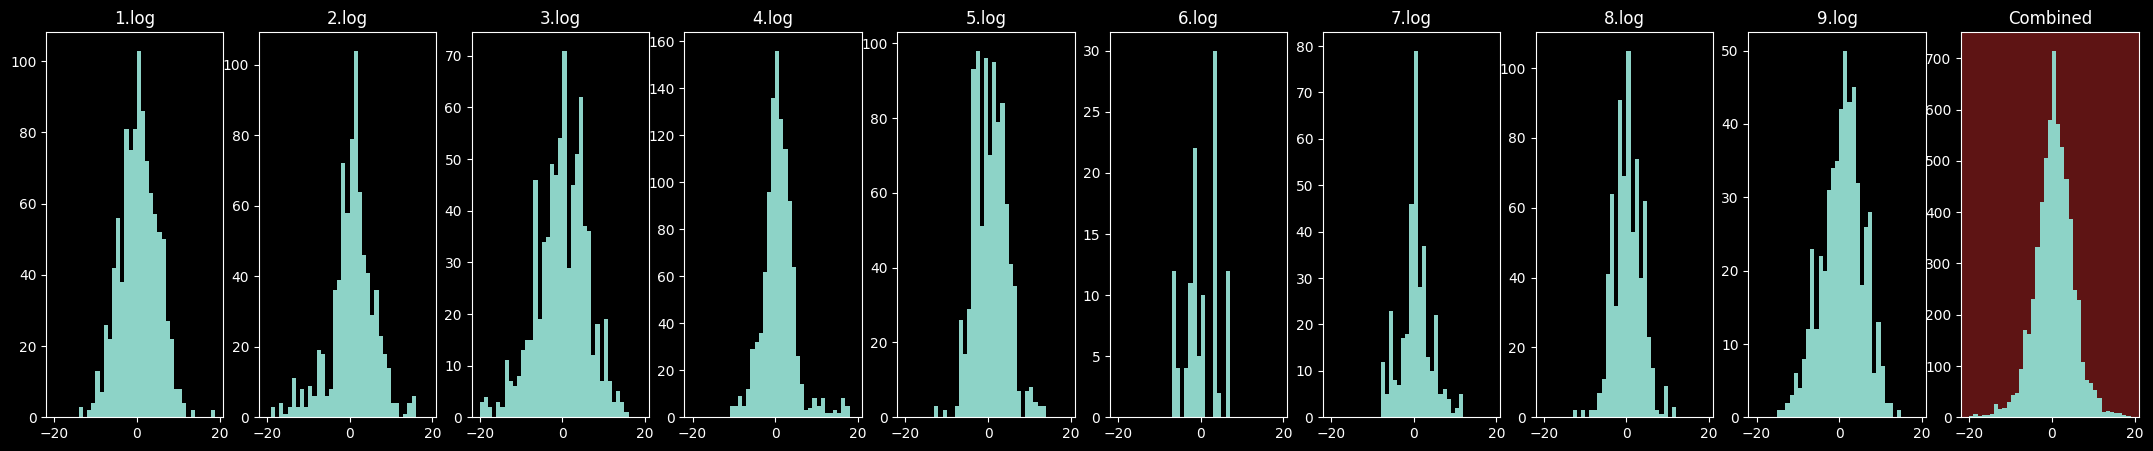

In [37]:
range_trial_rss_diffs_in_blocks(range_logs, 5)

### Ten Packet Differences

The difference is taken between the current packet and the packet at the same gamma in ten transmitter-rotations' time (approximately 20 seconds later). Examine the RSS in 30 degree blocks using histograms, and then all angles combined into one histogram.

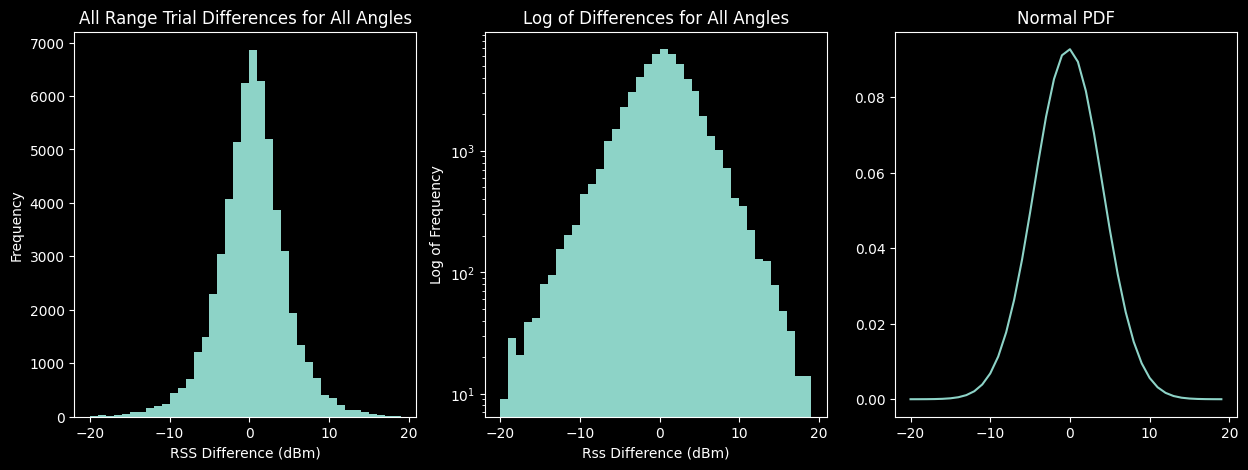

In [43]:
combined_rss_at_gamma_analysis(range_logs, 10)

#### -15 to 15 Degrees

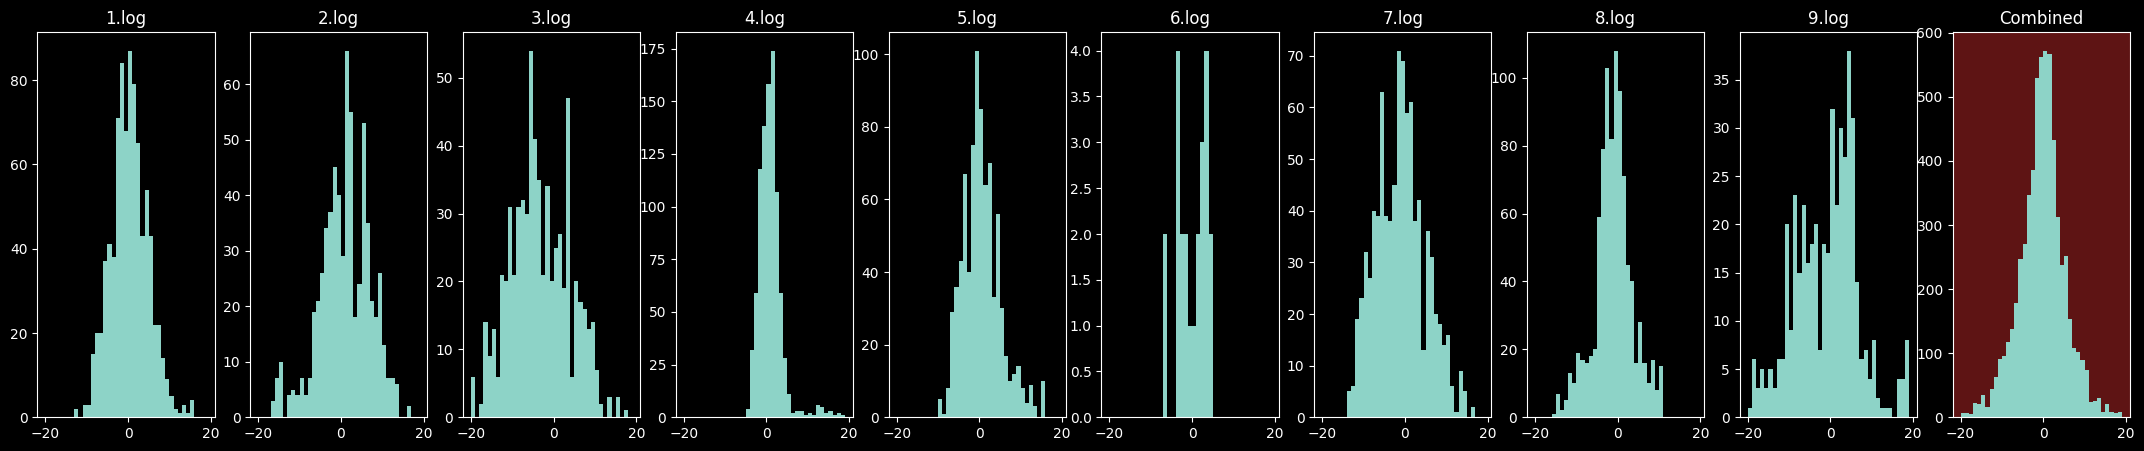

#### 15 to 45 Degrees

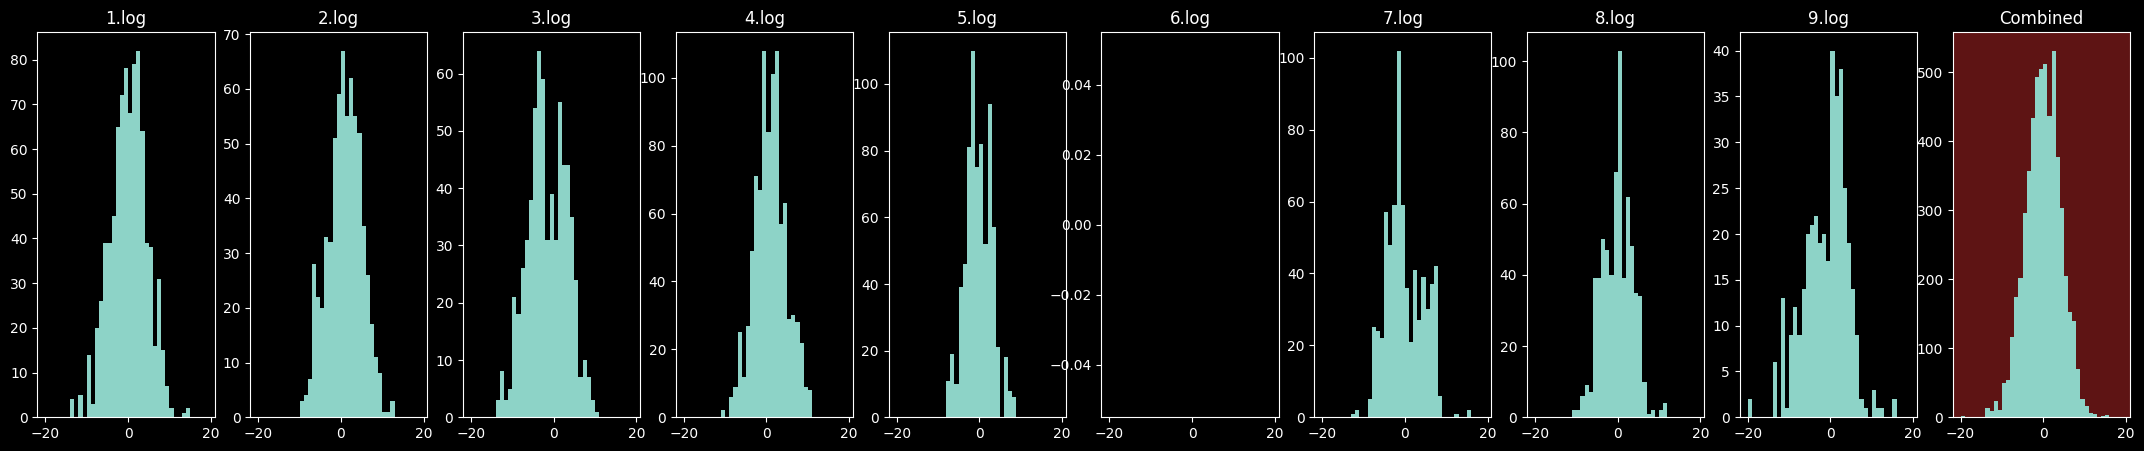

#### 45 to 75 Degrees

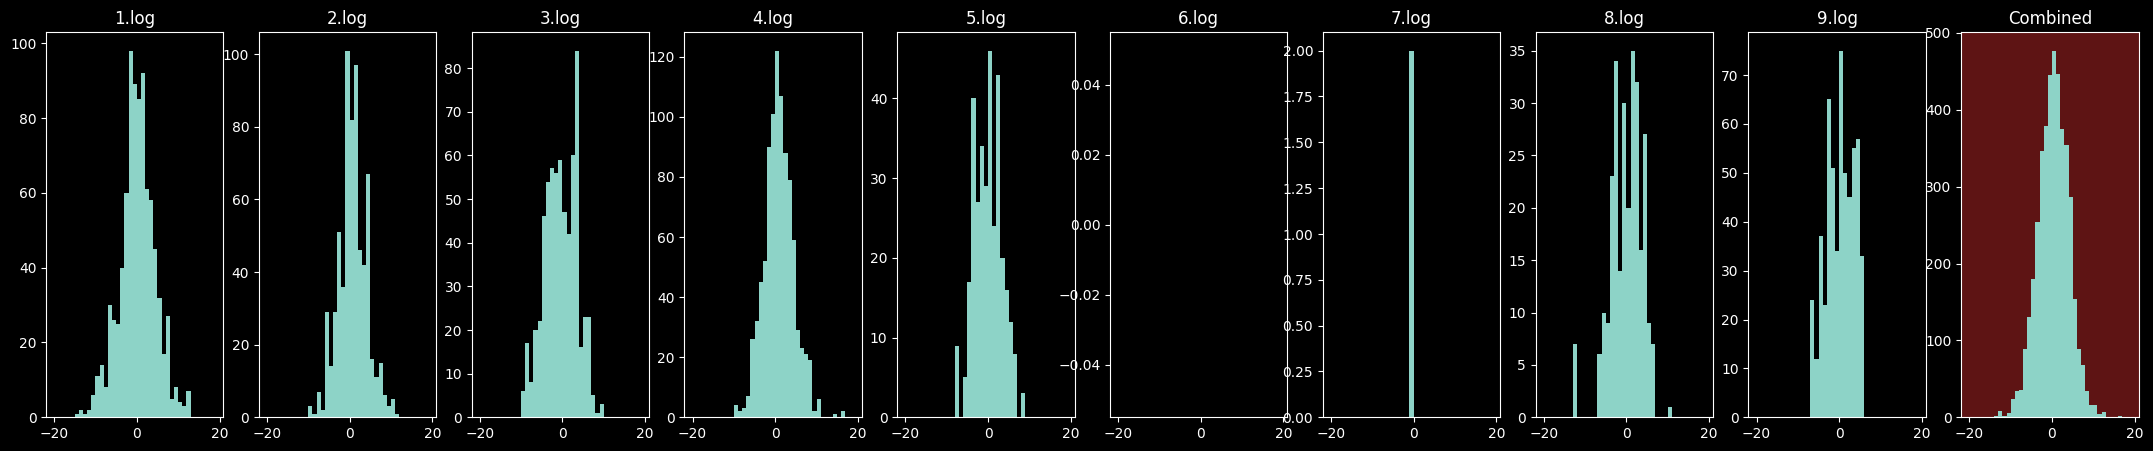

#### 75 to 105 Degrees

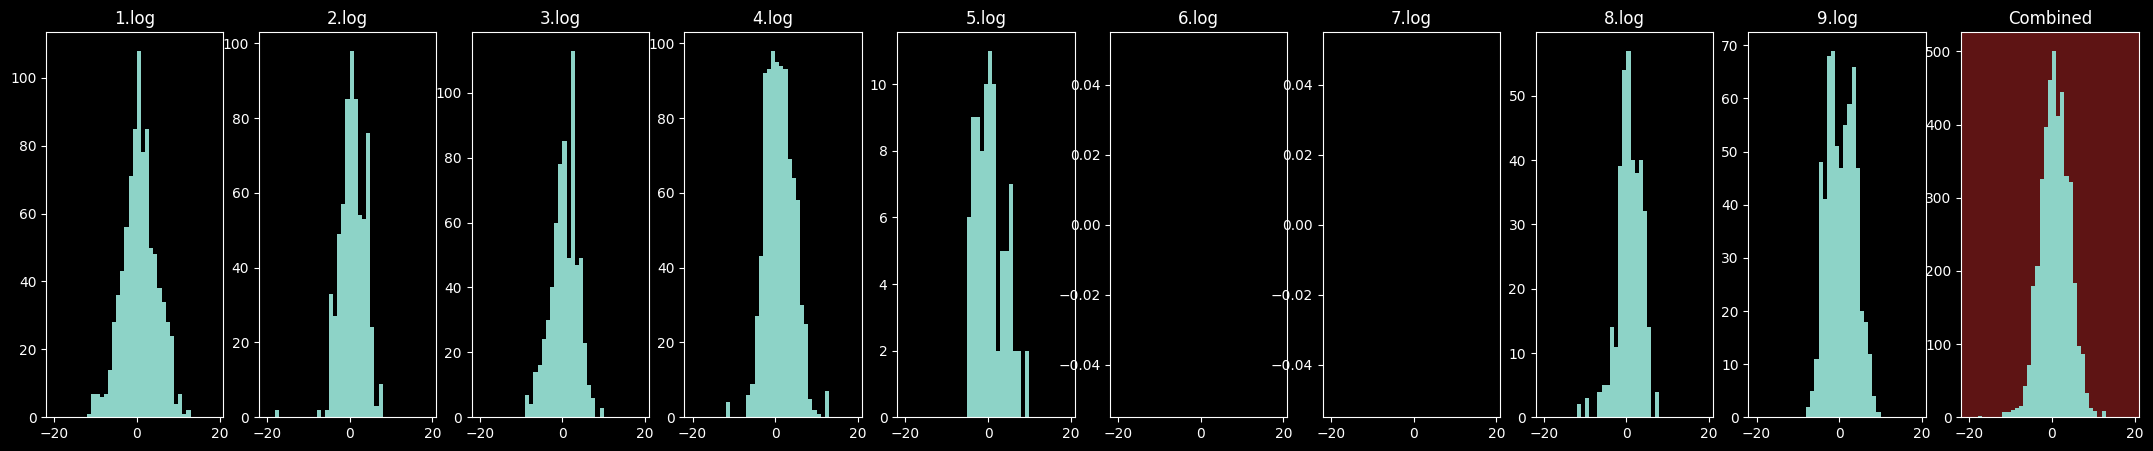

#### 105 to 135 Degrees

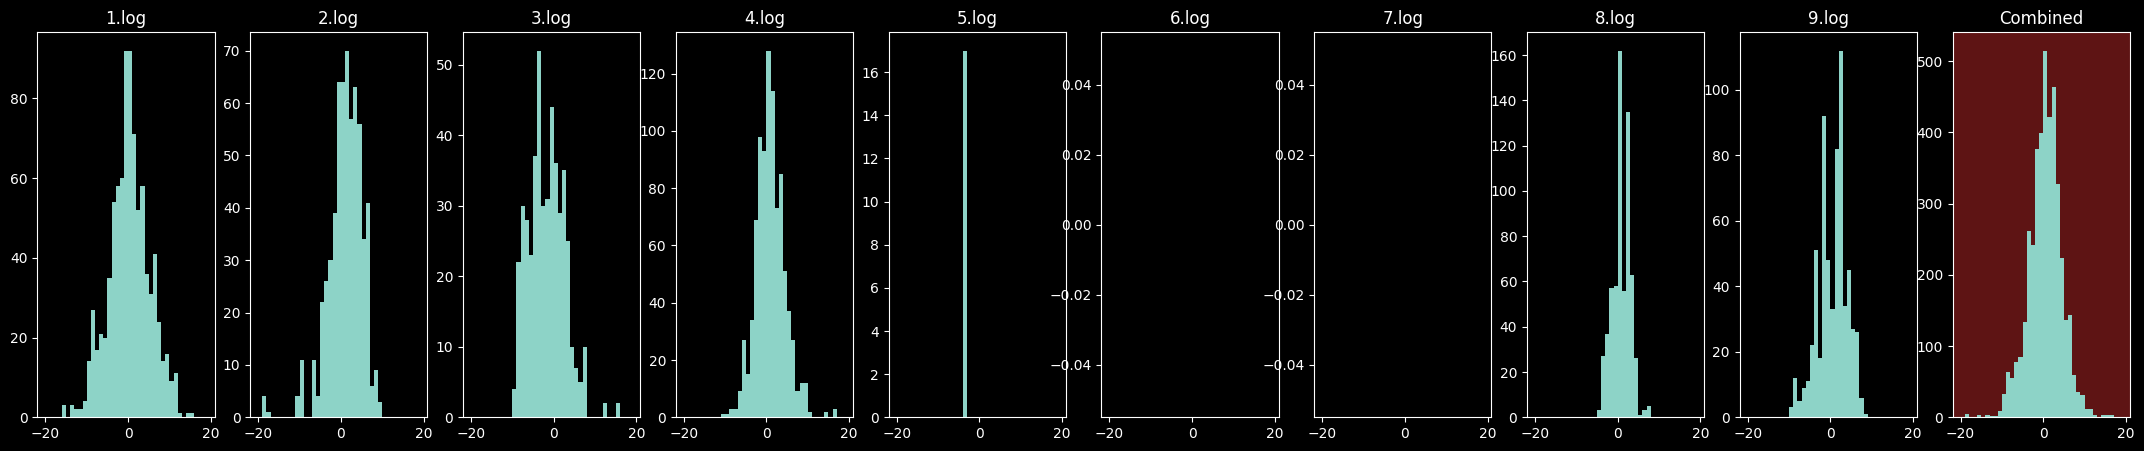

#### 135 to 165 Degrees

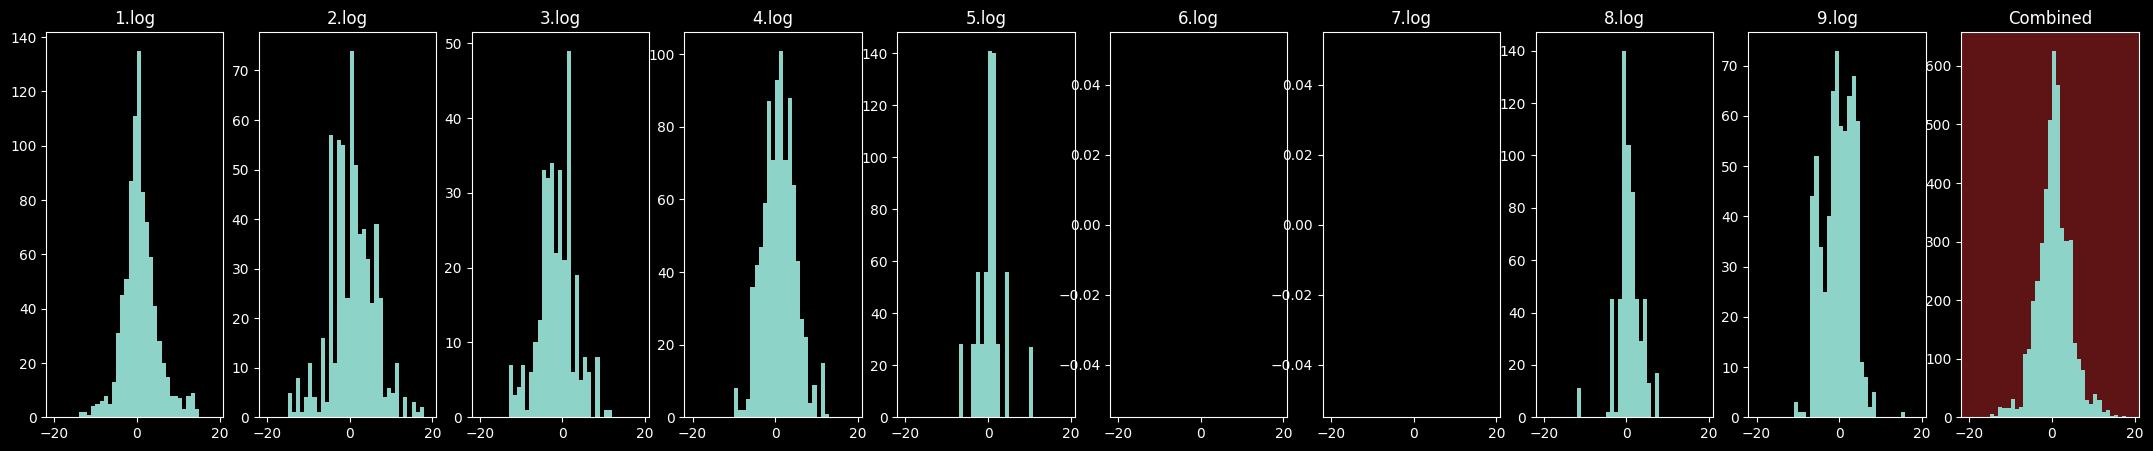

#### 165 to 195 Degrees

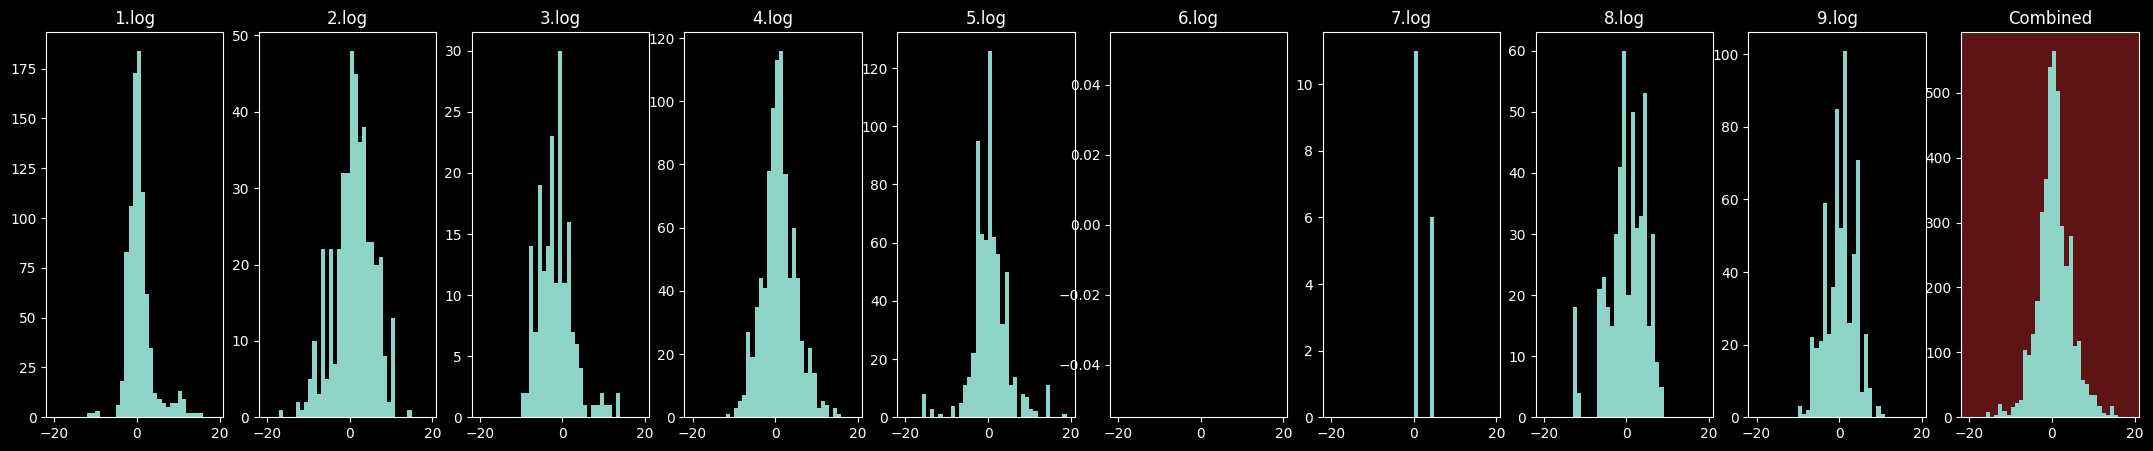

#### 195 to 225 Degrees

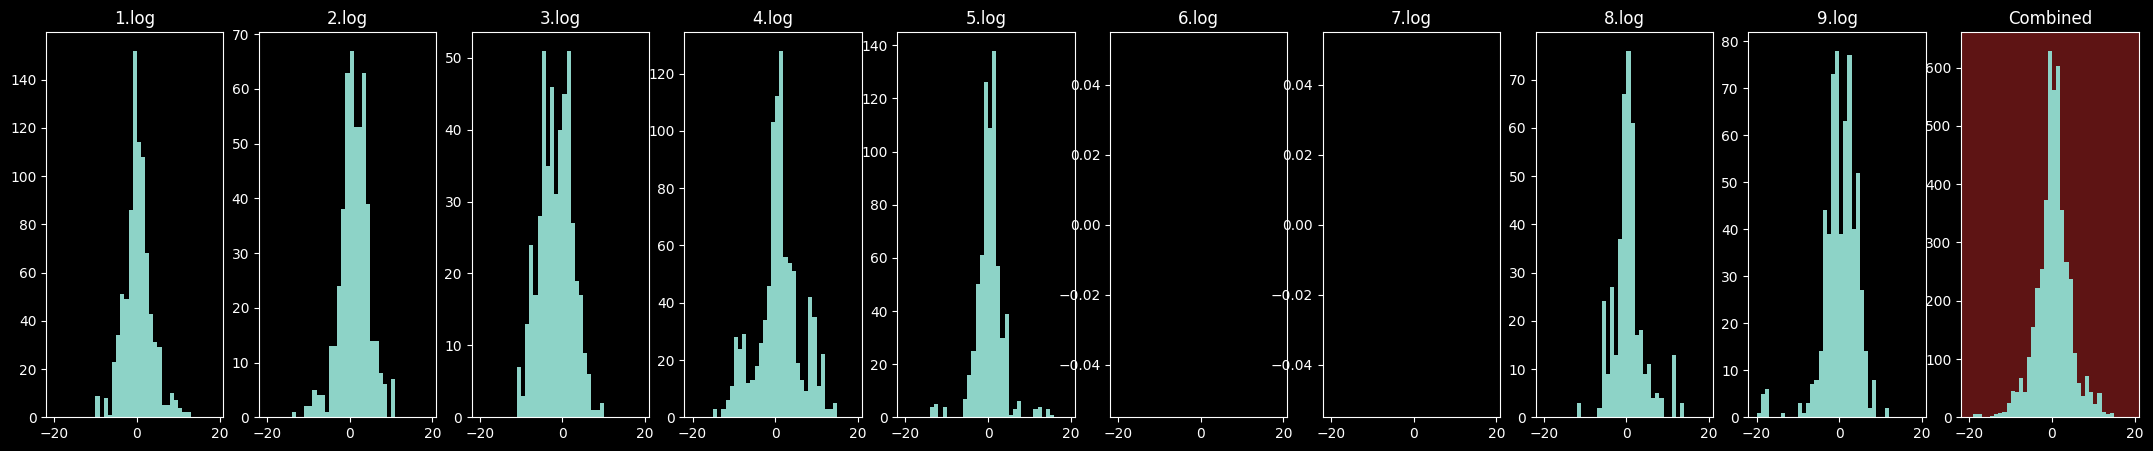

#### 225 to 255 Degrees

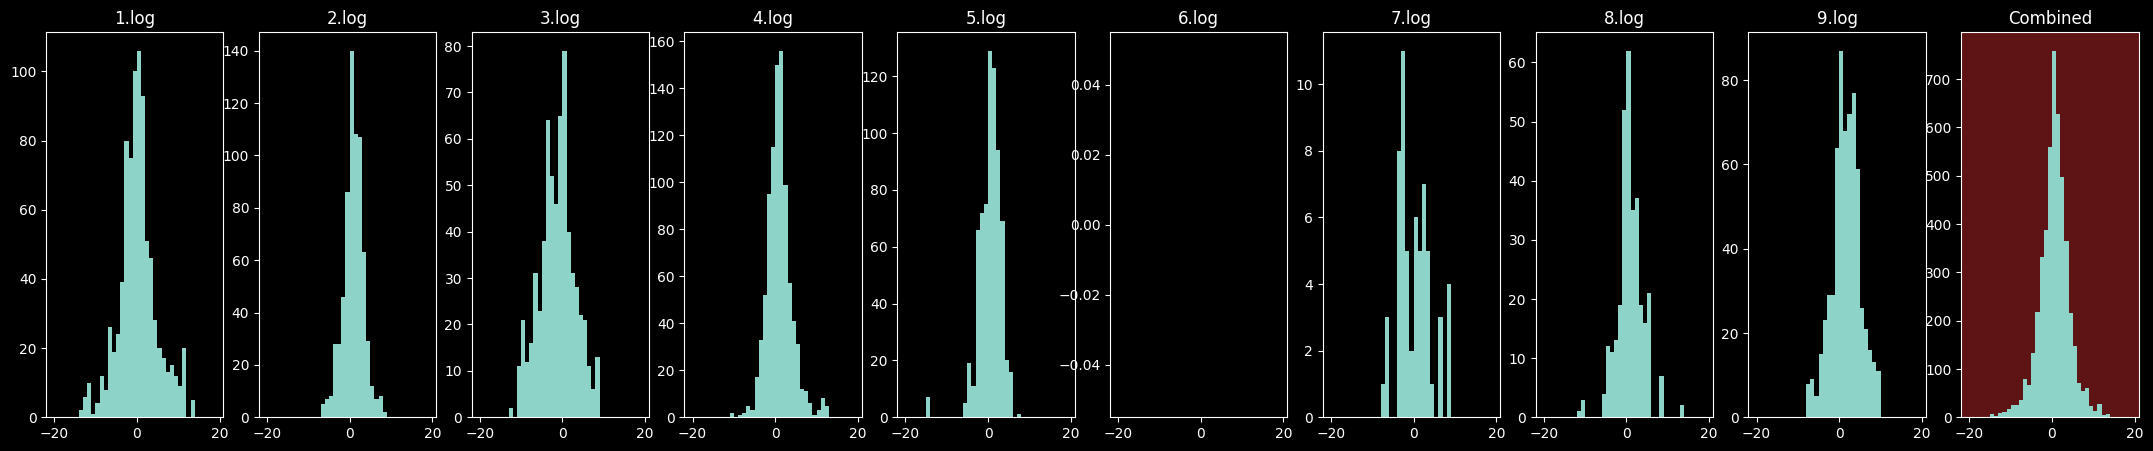

#### 255 to 285 Degrees

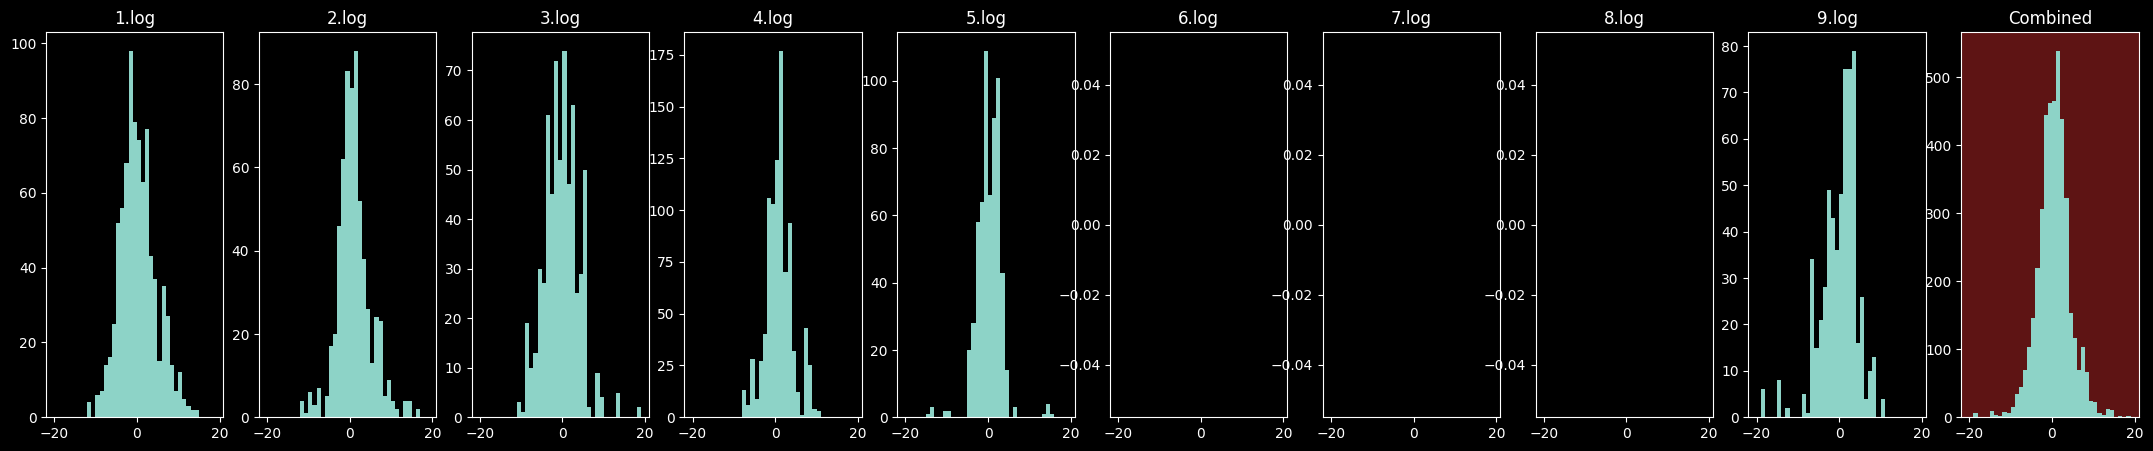

#### 285 to 315 Degrees

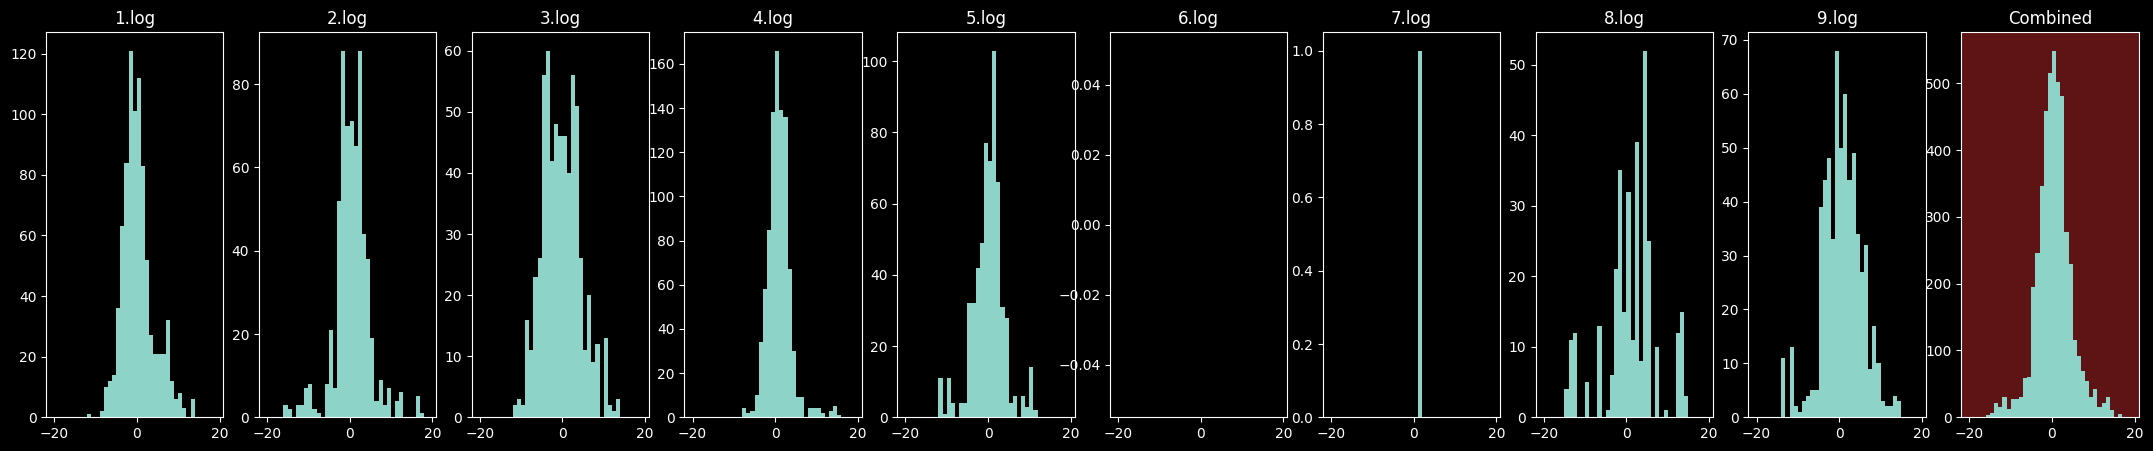

#### 315 to 345 Degrees

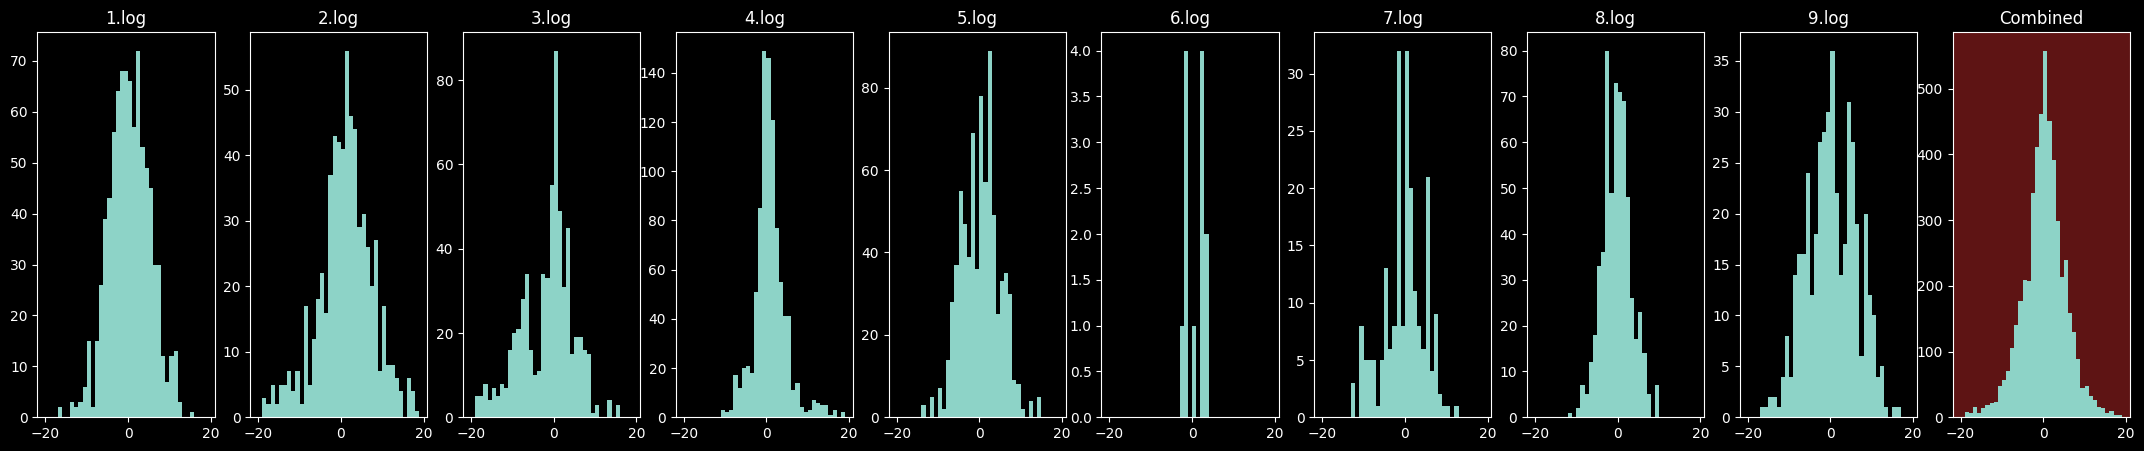

In [39]:
range_trial_rss_diffs_in_blocks(range_logs, 10)